# 🚗🔍 Notebook 3: Master Pipeline — End-to-End ALPR
## Indonesian ALPR System: Detection → Enhancement → OCR → Validation

---

### 📋 Deskripsi
Notebook ini merupakan **integrasi akhir** dari seluruh komponen ALPR pipeline:

```
INPUT (Foto/Video Kendaraan)
         │
         ▼
┌─────────────────────┐
│  YOLO Plate Detector │  ← NB1: best YOLO weights
│  (Stage 1)          │
└────────┬────────────┘
         │  Bounding Box
         ▼
┌─────────────────────┐
│  Plate Crop         │
│  + Perspective      │  ← Stage 2: OpenCV Geometry
│    Correction       │
│  + Image Enhancement│  (No training needed)
└────────┬────────────┘
         │  Crop plat terluruskan
         ▼
┌─────────────────────┐
│  TrOCR Recognizer   │  ← NB2: best TrOCR weights
│  (Stage 3)          │
└────────┬────────────┘
         │  Raw text: 'B1234XYZ'
         ▼
┌─────────────────────┐
│  Post-Processing    │  ← Stage 4: Regex + Char Correction
│  (Stage 4)          │  (No training needed)
└────────┬────────────┘
         │
         ▼
    'B 1234 XYZ'  ✅
```

### 🔬 Eksperimen Pipeline
| Pipeline | YOLO | TrOCR | Preprocessing | Post-Process | Target |
|:---------|:-----|:------|:-------------:|:------------:|:------:|
| Pipeline-A | YOLO11n | trocr-small | Standard | Minimal | Baseline cepat |
| Pipeline-B | YOLO11s | trocr-base | Standard | Format Regex | Baseline akurasi |
| **Pipeline-C** | **YOLO11s** | **trocr-base** | **Enhanced** | **Full Post-Process** | **Recommended** |
| Pipeline-D | YOLO11m | trocr-base (synth→real) | Enhanced | Full Post-Process | Research/Advanced |

### 📊 Metrik Evaluasi End-to-End
| Tahap | Metrik |
|:------|:-------|
| Detection | Precision, Recall, mAP@50, mAP@50:95 |
| OCR | CER, Exact Match Accuracy |
| **End-to-End** | **Pipeline Accuracy, Avg Processing Time/frame** |


---
## 🔧 Bagian 0: Verifikasi GPU & Environment

In [1]:
# ============================================================
# Cell 0.1 — Download Result.zip dari Google Drive
# ============================================================
# Result.zip berisi TIGA FOLDER:
#
#   Result.zip/
#   |-- Plate Detector Weight/             <- YOLO dari NB1 (~25 MB)
#   |   |-- yolo_plate_exp_a_best.pt
#   |   |-- yolo_plate_exp_b_best.pt
#   |   `-- model_registry.json
#   |-- OCR Extraction Text Weight EXP 2/  <- TrOCR dari NB2 Exp-B 50 epoch (~1.3 GB)
#   |   |-- model.safetensors
#   |   |-- config.json, generation_config.json
#   |   |-- processor_config.json
#   |   |-- tokenizer.json, tokenizer_config.json
#   |   `-- training_args.bin
#   `-- plate_text_dataset/                <- Dataset evaluasi (nested folder)
#       `-- plate_text_dataset/            <- folder dalam (isi sebenarnya)
#           |-- label.csv
#           `-- dataset/
#               |-- AA1234BB.jpg
#               `-- ... (1863 gambar crop plat)
#
# CARA MENDAPATKAN FILE ID DRIVE:
#   1. Upload Result.zip ke Google Drive
#   2. Klik kanan -> Share -> "Anyone with the link can view"
#   3. Salin File ID dari URL:
#      https://drive.google.com/file/d/<FILE_ID>/view
# ============================================================

GDRIVE_RESULT_ID = "1rz0RDtXDfv9xv9zx8XuxIFeHKuMudRi0"   # <- File ID Result.zip (Exp-B 50 epoch)

# ─────────────────────────────────────────────────────────────────────
import os, sys
from pathlib import Path

WORKING_DIR  = Path("/kaggle/working")
RESULT_ZIP   = WORKING_DIR / "Result.zip"
YOLO_DIR     = WORKING_DIR / "Plate Detector Weight"
OCR_DIR      = WORKING_DIR / "OCR Extraction Text Weight EXP 2"
DATASET_DIR  = WORKING_DIR / "plate_text_dataset"

# Struktur dataset setelah ekstraksi (nested folder):
#   /kaggle/working/plate_text_dataset/plate_text_dataset/label.csv
#   /kaggle/working/plate_text_dataset/plate_text_dataset/dataset/*.jpg
DATASET_INNER = DATASET_DIR / "plate_text_dataset"

def _dataset_ready():
    return (
        DATASET_DIR.exists() and (
            (DATASET_DIR / "label.csv").exists() or           # flat structure
            (DATASET_INNER / "label.csv").exists()            # nested structure
        )
    )

# Cek apakah sudah diekstrak sebelumnya
yolo_ready    = YOLO_DIR.exists()   and (YOLO_DIR / "yolo_plate_exp_b_best.pt").exists()
ocr_ready     = OCR_DIR.exists()    and (OCR_DIR  / "model.safetensors").exists()
dataset_ready = _dataset_ready()

if yolo_ready and ocr_ready and dataset_ready:
    print("[OK]  Semua sudah tersedia, skip download.")
    print(f"      YOLO   : {YOLO_DIR}")
    print(f"      TrOCR  : {OCR_DIR}")
    print(f"      Dataset: {DATASET_DIR}")

elif GDRIVE_RESULT_ID == "YOUR_GDRIVE_FILE_ID_HERE":
    print("[WARN] GDRIVE_RESULT_ID belum diisi!")
    print("       Isi File ID Google Drive Result.zip, lalu run ulang cell ini.")

else:
    try:
        import gdown
    except ImportError:
        os.system("pip install gdown -q")
        import gdown

    print("[INFO] Mengunduh Result.zip dari Google Drive ...")
    url = f"https://drive.google.com/uc?id={GDRIVE_RESULT_ID}"
    gdown.download(url, str(RESULT_ZIP), quiet=False)

    if not RESULT_ZIP.exists() or RESULT_ZIP.stat().st_size < 10_000:
        print("[ERROR] Download gagal atau file terlalu kecil.")
        print("        Periksa File ID dan pastikan akses Drive 'Anyone with the link'.")
        sys.exit(1)

    print(f"[INFO] Mengekstrak Result.zip ke {WORKING_DIR} ...")
    os.system(f'unzip -q "{RESULT_ZIP}" -d "{WORKING_DIR}"')

    try:
        RESULT_ZIP.unlink()
        print("[INFO] Result.zip dihapus untuk menghemat storage.")
    except Exception:
        pass

    # Re-cek setelah ekstraksi
    yolo_ready    = YOLO_DIR.exists()   and (YOLO_DIR / "yolo_plate_exp_b_best.pt").exists()
    ocr_ready     = OCR_DIR.exists()    and (OCR_DIR  / "model.safetensors").exists()
    dataset_ready = _dataset_ready()

    print()
    print("=" * 60)
    print("  HASIL EKSTRAKSI RESULT.ZIP")
    print("=" * 60)

    if yolo_ready:
        pts = [f.name for f in YOLO_DIR.glob("*.pt")]
        print(f"  [OK]   Plate Detector Weight  : {pts}")
    else:
        print("  [FAIL] Plate Detector Weight tidak ditemukan!")
        print("         Pastikan zip berisi FOLDER 'Plate Detector Weight/'")

    if ocr_ready:
        size_mb = (OCR_DIR / "model.safetensors").stat().st_size / 1024**2
        print(f"  [OK]   OCR EXP 2 (50 epoch)   : model.safetensors ({size_mb:.0f} MB)")
    else:
        print("  [FAIL] OCR Extraction Text Weight EXP 2 tidak ditemukan!")
        print("         Pastikan zip berisi FOLDER 'OCR Extraction Text Weight EXP 2/'")

    if dataset_ready:
        # Tentukan lokasi label.csv yang sebenarnya (flat atau nested)
        label_dir = DATASET_INNER if (DATASET_INNER / "label.csv").exists() else DATASET_DIR
        img_dir   = label_dir / "dataset"
        n_imgs    = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
        print(f"  [OK]   Dataset evaluasi       : label.csv + {n_imgs} gambar")
        print(f"         Path: {label_dir}")
    else:
        print("  [WARN] plate_text_dataset/ tidak ditemukan.")
        print("         Evaluasi akan dilewati (gambar uji = 0).")
        print("         Tambahkan folder plate_text_dataset/ ke Result.zip.")

    print("=" * 60)

[INFO] Mengunduh Result.zip dari Google Drive ...


Downloading...
From (original): https://drive.google.com/uc?id=1rz0RDtXDfv9xv9zx8XuxIFeHKuMudRi0
From (redirected): https://drive.google.com/uc?id=1rz0RDtXDfv9xv9zx8XuxIFeHKuMudRi0&confirm=t&uuid=4cb78a01-b589-400b-9075-610ece6b92ac
To: /kaggle/working/Result.zip
100%|██████████| 2.74G/2.74G [00:39<00:00, 68.9MB/s]


[INFO] Mengekstrak Result.zip ke /kaggle/working ...
[INFO] Result.zip dihapus untuk menghemat storage.

  HASIL EKSTRAKSI RESULT.ZIP
  [OK]   Plate Detector Weight  : ['yolo_plate_exp_b_best.pt', 'yolo_plate_exp_c_best.pt', 'yolo_plate_exp_a_best.pt']
  [OK]   OCR EXP 2 (50 epoch)   : model.safetensors (1274 MB)
  [OK]   Dataset evaluasi       : label.csv + 1863 gambar
         Path: /kaggle/working/plate_text_dataset/plate_text_dataset


In [2]:
# ============================================================
# Cell 0.1 — Verifikasi GPU Kaggle T4x2
# ============================================================
import torch
import multiprocessing
import os

print("=" * 60)
print("GPU & CUDA ENVIRONMENT VERIFICATION")
print("=" * 60)
print(f"PyTorch Version    : {torch.__version__}")
print(f"CUDA Available     : {torch.cuda.is_available()}")
print(f"CUDA Version       : {torch.version.cuda}")
print(f"Number of GPU(s)   : {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU [{i}] Name    : {props.name}")
    print(f"  GPU [{i}] VRAM    : {props.total_memory / 1024**3:.1f} GB")

DEVICE_STR   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPU        = torch.cuda.device_count()
NUM_WORKERS  = min(4, multiprocessing.cpu_count())
print(f"\nDevice             : {DEVICE_STR}")
print(f"N_GPU              : {N_GPU}")
print(f"Num Workers        : {NUM_WORKERS}")
print("=" * 60)
print("✅ Environment verified.")

GPU & CUDA ENVIRONMENT VERIFICATION
PyTorch Version    : 2.10.0+cu128
CUDA Available     : True
CUDA Version       : 12.8
Number of GPU(s)   : 2
  GPU [0] Name    : Tesla T4
  GPU [0] VRAM    : 14.6 GB
  GPU [1] Name    : Tesla T4
  GPU [1] VRAM    : 14.6 GB

Device             : cuda
N_GPU              : 2
Num Workers        : 4
✅ Environment verified.


In [3]:
# ============================================================
# Cell 0.2 — Install & Import Library
# ============================================================
!pip install ultralytics transformers evaluate jiwer -q
!pip install opencv-python-headless Pillow -q

import ultralytics, transformers, evaluate as eval_lib
print(f"Ultralytics  : {ultralytics.__version__}")
print(f"Transformers : {transformers.__version__}")
print("✅ Library siap.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics  : 8.4.160
Transformers : 5.0.0
✅ Library siap.


---
## 📦 Bagian 1: Konfigurasi Path & Konstanta

In [4]:
# ============================================================
# Cell 1.1 — Konfigurasi Path Model & Dataset Evaluasi
# ============================================================
import os
from pathlib import Path

KAGGLE_INPUT   = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

# Folder yang dihasilkan dari ekstraksi Result.zip (Cell 0.1)
RESULT_YOLO_DIR = KAGGLE_WORKING / "Plate Detector Weight"
RESULT_OCR_DIR  = KAGGLE_WORKING / "OCR Extraction Text Weight EXP 2"

SEARCH_ROOTS = [
    RESULT_YOLO_DIR,                              # Result.zip — YOLO
    RESULT_OCR_DIR,                               # Result.zip — TrOCR
    KAGGLE_WORKING / "plate_text_dataset",        # Result.zip — Dataset evaluasi
    KAGGLE_WORKING / "weights",
    KAGGLE_WORKING / "ANPR",
    KAGGLE_WORKING,
    KAGGLE_INPUT,
    Path("d:/Deteksi Plat"),
    Path("."),
]

# ─── 1. Cari YOLO weights (.pt) ───────────────────────────────────────────────
YOLO_MODELS_DIR   = None
yolo_detected_files = {}

yolo_search_paths = [
    RESULT_YOLO_DIR,                                                   # Result.zip
    KAGGLE_INPUT / "yolov11-plate-detector" / "final_models",          # + Add Input NB1
    KAGGLE_INPUT / "yolov11-plate-detector",                            # + Add Input NB1 root
    KAGGLE_INPUT / "yolo-plate-models" / "final_models",
    KAGGLE_WORKING / "final_models",
    KAGGLE_WORKING / "weights" / "Plate Detector Weight",
] + SEARCH_ROOTS

for r in yolo_search_paths:
    if not r.exists():
        continue
    for p in r.rglob("*.pt"):
        name = p.name.lower()
        if "exp_a" in name or "exp-a" in name or "exp1" in name:
            yolo_detected_files.setdefault("Exp-A", p)
        elif "exp_b" in name or "exp-b" in name or "exp2" in name:
            yolo_detected_files.setdefault("Exp-B", p)
        elif "exp_c" in name or "exp-c" in name or "exp3" in name:
            yolo_detected_files.setdefault("Exp-C", p)
        elif "exp_d" in name or "exp-d" in name or "exp4" in name:
            yolo_detected_files.setdefault("Exp-D", p)
        if YOLO_MODELS_DIR is None and "plate" in name:
            YOLO_MODELS_DIR = p.parent

# ─── 2. Cari TrOCR model dir (berisi model.safetensors) ───────────────────────
OCR_MODELS_DIR   = None
ocr_detected_dirs = {}

ocr_search_paths = [
    RESULT_OCR_DIR,                                                        # Result.zip
    KAGGLE_INPUT / "trocr-text-extraction" / "final_ocr_models" / "ocr_exp_b",  # + Add Input NB2
    KAGGLE_INPUT / "trocr-text-extraction" / "final_ocr_models" / "ocr_exp_a",
    KAGGLE_INPUT / "trocr-text-extraction",                                # + Add Input NB2 root
    KAGGLE_INPUT / "trocr-plate-models" / "final_ocr_models",
    KAGGLE_WORKING / "final_ocr_models",
    KAGGLE_WORKING / "ocr_plate_recognizer" / "final_ocr_models",
] + SEARCH_ROOTS

for r in ocr_search_paths:
    if not r.exists():
        continue
    # Cek langsung apakah r sendiri berisi model.safetensors
    if (r / "model.safetensors").exists():
        p_name = r.name.lower()
        if "exp 1" in p_name or "exp_1" in p_name or "exp_a" in p_name or "exp-a" in p_name:
            ocr_detected_dirs.setdefault("Exp-A", r)
        elif "exp 2" in p_name or "exp_2" in p_name or "exp_b" in p_name or "exp-b" in p_name:
            ocr_detected_dirs.setdefault("Exp-B", r)
        elif "exp 3" in p_name or "exp_3" in p_name or "exp_c" in p_name or "exp-c" in p_name:
            ocr_detected_dirs.setdefault("Exp-C", r)
        elif "exp 4" in p_name or "exp_4" in p_name or "exp_d" in p_name or "exp-d" in p_name:
            ocr_detected_dirs.setdefault("Exp-D", r)
        else:
            # Folder namanya tidak mengandung exp-x, kemungkinan OCR EXP 2 dari Result.zip
            # Identifikasi dari path parent atau isi
            if r == RESULT_OCR_DIR:
                ocr_detected_dirs.setdefault("Exp-B", r)  # EXP 2 = Exp-B
        if OCR_MODELS_DIR is None:
            OCR_MODELS_DIR = r.parent if r != RESULT_OCR_DIR else r
        continue
    # Jika r adalah folder parent, cari subfolder ocr_exp_*
    for p in r.rglob("model.safetensors"):
        parent_dir = p.parent
        p_name = parent_dir.name.lower()
        if "exp 1" in p_name or "exp_1" in p_name or "exp_a" in p_name or "exp-a" in p_name:
            ocr_detected_dirs.setdefault("Exp-A", parent_dir)
        elif "exp 2" in p_name or "exp_2" in p_name or "exp_b" in p_name or "exp-b" in p_name:
            ocr_detected_dirs.setdefault("Exp-B", parent_dir)
        elif "exp 3" in p_name or "exp_3" in p_name or "exp_c" in p_name or "exp-c" in p_name:
            ocr_detected_dirs.setdefault("Exp-C", parent_dir)
        elif "exp 4" in p_name or "exp_4" in p_name or "exp_d" in p_name or "exp-d" in p_name:
            ocr_detected_dirs.setdefault("Exp-D", parent_dir)
        if OCR_MODELS_DIR is None:
            OCR_MODELS_DIR = parent_dir.parent

# Fallback: jika OCR_MODELS_DIR masih None tapi ocr_detected_dirs ada
if OCR_MODELS_DIR is None and ocr_detected_dirs:
    OCR_MODELS_DIR = list(ocr_detected_dirs.values())[0].parent
if YOLO_MODELS_DIR is None and yolo_detected_files:
    YOLO_MODELS_DIR = list(yolo_detected_files.values())[0].parent

# ─── 3. Cari Dataset Evaluasi (label.csv) ─────────────────────────────────────
DS_TEXT_ROOT = None
DS_TEXT_CSV  = None
DS_TEXT_IMGS = None
# Cari dari WORKING_DIR/plate_text_dataset/ terlebih dahulu (dari Result.zip)
# Mendukung struktur flat (label.csv langsung) maupun nested
# (plate_text_dataset/plate_text_dataset/label.csv)
_priority_roots = [
    KAGGLE_WORKING / "plate_text_dataset" / "plate_text_dataset",  # nested
    KAGGLE_WORKING / "plate_text_dataset",                          # flat
] + SEARCH_ROOTS
for r in _priority_roots:
    if not r.exists():
        continue
    for p in r.rglob("label.csv"):
        DS_TEXT_CSV  = p
        DS_TEXT_ROOT = p.parent
        cand = p.parent / "dataset"
        if cand.exists():
            DS_TEXT_IMGS = cand
        break
    if DS_TEXT_CSV:
        break

# ─── Output Directory ─────────────────────────────────────────────────────────
WORK_DIR = KAGGLE_WORKING / "alpr_master_pipeline"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# ─── Tampilkan Ringkasan ───────────────────────────────────────────────────────
print(f"Work Directory  : {WORK_DIR}")
print()
print("=" * 65)
print("PATH VERIFICATION — MASTER PIPELINE ALPR")
print("=" * 65)
items = [
    (YOLO_MODELS_DIR, "YOLO Models Dir (NB1)"),
    (OCR_MODELS_DIR,  "OCR Models Dir  (NB2)"),
    (DS_TEXT_CSV,     "Evaluation Dataset CSV"),
    (DS_TEXT_IMGS,    "Evaluation Dataset Images"),
]
for path, label in items:
    found  = path is not None and Path(str(path)).exists()
    status = "[OK] " if found else "[!!!]"
    print(f"  {status} {label:<35}: {path if found else 'TIDAK DITEMUKAN'}")

print()
print("  Model yang berhasil dideteksi:")
if yolo_detected_files:
    for k, v in yolo_detected_files.items():
        print(f"    YOLO  [{k}]: {v.name}")
else:
    print("    YOLO  : Tidak ada — pastikan Result.zip sudah diekstrak atau")
    print("            gunakan '+ Add Input' untuk melampirkan output Notebook 1 (yolov11-plate-detector)")

if ocr_detected_dirs:
    for k, v in ocr_detected_dirs.items():
        size = (v / "model.safetensors").stat().st_size / 1024**2 if (v / "model.safetensors").exists() else 0
        print(f"    TrOCR [{k}]: {v.name} ({size:.0f} MB)")
else:
    print("    TrOCR : Tidak ada — pastikan Result.zip sudah diekstrak atau")
    print("            gunakan '+ Add Input' untuk melampirkan output Notebook 2 (trocr-text-extraction)")
print("=" * 65)

Work Directory  : /kaggle/working/alpr_master_pipeline

PATH VERIFICATION — MASTER PIPELINE ALPR
  [OK]  YOLO Models Dir (NB1)              : /kaggle/working/Plate Detector Weight
  [OK]  OCR Models Dir  (NB2)              : /kaggle/working/OCR Extraction Text Weight EXP 2
  [OK]  Evaluation Dataset CSV             : /kaggle/working/plate_text_dataset/plate_text_dataset/label.csv
  [OK]  Evaluation Dataset Images          : /kaggle/working/plate_text_dataset/plate_text_dataset/dataset

  Model yang berhasil dideteksi:
    YOLO  [Exp-B]: yolo_plate_exp_b_best.pt
    YOLO  [Exp-C]: yolo_plate_exp_c_best.pt
    YOLO  [Exp-A]: yolo_plate_exp_a_best.pt
    TrOCR [Exp-B]: OCR Extraction Text Weight EXP 2 (1274 MB)


In [5]:
# ============================================================
# Cell 1.2 — Konstanta Global Pipeline
# ============================================================
import random
import numpy as np

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ─── YOLO Inference Config ─────────────────────────────────────────────────────
YOLO_IMGSZ      = 640
YOLO_CONF       = 0.20   # Confidence threshold deteksi
YOLO_IOU        = 0.45   # IoU threshold NMS
CLASS_NAMES     = ['license_plate']

# ─── OCR Config ────────────────────────────────────────────────────────────────
OCR_IMG_WIDTH   = 384
OCR_IMG_HEIGHT  = 128
MAX_TOKEN_LEN   = 12
NUM_BEAMS       = 4    # Beam search untuk TrOCR

# ─── Karakter Valid Plat Indonesia ─────────────────────────────────────────────
VALID_CHARS     = set('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')

# ─── Ambiguity Map untuk Post-Processing ───────────────────────────────────────
# Karakter yang sering salah prediksi di posisi tertentu
# Jika di posisi HURUF tetapi OCR baca digit → koreksi
DIGIT_TO_CHAR   = {'0':'O','1':'I','2':'Z','4':'A','5':'S','6':'G','8':'B'}
# Jika di posisi DIGIT tetapi OCR baca huruf → koreksi
CHAR_TO_DIGIT   = {'O':'0','I':'1','Z':'2','A':'4','S':'5','G':'6','B':'8','Q':'0'}

print("=" * 55)
print("GLOBAL CONSTANTS")
print("=" * 55)
print(f"YOLO Conf Threshold : {YOLO_CONF}")
print(f"YOLO IOU Threshold  : {YOLO_IOU}")
print(f"OCR Image Size      : {OCR_IMG_WIDTH}x{OCR_IMG_HEIGHT}")
print(f"Num Beams (TrOCR)   : {NUM_BEAMS}")
print(f"Ambiguity Correction: Digit→Char: {DIGIT_TO_CHAR}")
print(f"                      Char→Digit: {CHAR_TO_DIGIT}")

GLOBAL CONSTANTS
YOLO Conf Threshold : 0.3
YOLO IOU Threshold  : 0.45
OCR Image Size      : 384x128
Num Beams (TrOCR)   : 4
Ambiguity Correction: Digit→Char: {'0': 'O', '1': 'I', '5': 'S', '8': 'B', '6': 'G'}
                      Char→Digit: {'O': '0', 'I': '1', 'S': '5', 'B': '8', 'G': '6', 'Z': '2', 'Q': '0'}


---
## 🎯 Bagian 2: Stage 1 — YOLO Plate Detector

In [6]:
# ============================================================
# Cell 2.1 — Load Semua YOLO Model dari NB1
# ============================================================
from ultralytics import YOLO
import json

yolo_models = {}

# 1. Coba load dari yolo_detected_files (Auto-detect pintar)
if 'yolo_detected_files' in globals() and yolo_detected_files:
    for exp_id, pt_path in yolo_detected_files.items():
        if pt_path.exists():
            try:
                yolo_models[exp_id] = YOLO(str(pt_path))
                print(f"✅ YOLO [{exp_id}] loaded: {pt_path.name}")
            except Exception as e:
                print(f"❌ Gagal load YOLO [{exp_id}]: {e}")

# 2. Fallback: coba dari registry jika belum ada yang ter-load
if not yolo_models and YOLO_MODELS_DIR:
    yolo_registry_path = YOLO_MODELS_DIR / 'model_registry.json'
    if yolo_registry_path.exists():
        with open(yolo_registry_path) as f:
            yolo_registry = json.load(f)
        for exp_id, info in yolo_registry.items():
            pt_path = YOLO_MODELS_DIR / info.get('filename', '')
            if pt_path.exists():
                try:
                    yolo_models[exp_id] = YOLO(str(pt_path))
                    print(f"✅ YOLO [{exp_id}] loaded: {pt_path.name}")
                except Exception as e:
                    print(f"❌ Gagal load YOLO [{exp_id}]: {e}")

print(f"\nTotal YOLO model loaded: {len(yolo_models)}")

✅ YOLO [Exp-B] loaded: yolo_plate_exp_b_best.pt
✅ YOLO [Exp-C] loaded: yolo_plate_exp_c_best.pt
✅ YOLO [Exp-A] loaded: yolo_plate_exp_a_best.pt

Total YOLO model loaded: 3


In [7]:
# ============================================================
# Cell 2.2 — Fungsi Deteksi YOLO (per gambar)
# ============================================================
from PIL import Image
import numpy as np

def detect_plates(yolo_model, image_input, conf=YOLO_CONF, iou=YOLO_IOU, imgsz=YOLO_IMGSZ):
    """
    Deteksi bounding box plat nomor menggunakan YOLO.

    Args:
        yolo_model  : YOLO model instance
        image_input : str path, PIL Image, atau numpy array (BGR/RGB)
        conf        : confidence threshold
        iou         : IoU threshold untuk NMS
        imgsz       : ukuran input YOLO

    Returns:
        list of dict:
            {'xyxy': [x1,y1,x2,y2], 'conf': float, 'cls': int}
    """
    results = yolo_model(
        source  = image_input,
        conf    = conf,
        iou     = iou,
        imgsz   = imgsz,
        verbose = False,
    )

    detections = []
    for r in results:
        for box in r.boxes:
            xyxy = box.xyxy[0].cpu().numpy().astype(int).tolist()
            detections.append({
                'xyxy': xyxy,
                'conf': float(box.conf[0].cpu()),
                'cls' : int(box.cls[0].cpu()),
            })
    return detections


def crop_plate_from_image(image_np_bgr, xyxy, pad_x_pct=0.08, pad_y_pct=0.04):
    """
    Crop area plat dari gambar dengan padding horizontal lebih lebar (8%)
    untuk mencegah huruf depan (prefix) atau huruf belakang (suffix) terpotong.

    Args:
        image_np_bgr : numpy array gambar (H, W, 3) BGR
        xyxy         : [x1, y1, x2, y2] bounding box piksel
        pad_x_pct    : padding horizontal (0.08 = 8% lebar bbox)
        pad_y_pct    : padding vertikal (0.04 = 4% tinggi bbox)

    Returns:
        numpy array crop (RGB)
    """
    h, w = image_np_bgr.shape[:2]
    x1, y1, x2, y2 = xyxy

    bw = x2 - x1
    bh = y2 - y1
    pad_x = int(bw * pad_x_pct)
    pad_y = int(bh * pad_y_pct)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)

    crop_bgr = image_np_bgr[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    return crop_rgb


print("✅ Fungsi deteksi YOLO siap.")

✅ Fungsi deteksi YOLO siap.


---
## 📐 Bagian 3: Stage 2 — Geometry Correction & Image Enhancement

Tahap ini tidak membutuhkan model yang dilatih. Menggunakan algoritma OpenCV:
```
Crop Plat (mungkin miring/berperspektif)
         │
         ├─→ [Perspective Correction]
         │    Deteksi 4 sudut plat via contour → Warp perspective
         │
         ├─→ [CLAHE Enhancement]
         │    LAB colorspace → CLAHE pada L channel → Bilateral Filter
         │
         ▼
Crop plat terluruskan & kontras optimal
```

In [8]:
# ============================================================
# Cell 3.1 — Fungsi Perspective Correction (Four-Point Transform)
# ============================================================
import cv2
import numpy as np

def order_points(pts):
    """
    Urutkan 4 titik sudut: [top-left, top-right, bottom-right, bottom-left].
    Diperlukan untuk homography transform yang konsisten.
    """
    rect = np.zeros((4, 2), dtype='float32')
    s    = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left: jumlah terkecil
    rect[2] = pts[np.argmax(s)]   # bottom-right: jumlah terbesar
    diff     = np.diff(pts, axis=1)
    rect[1]  = pts[np.argmin(diff)]  # top-right: selisih terkecil
    rect[3]  = pts[np.argmax(diff)]  # bottom-left: selisih terbesar
    return rect


def four_point_transform(image, pts):
    """
    Terapkan perspektif transform (homography) berdasarkan 4 titik sudut.
    Output selalu berupa gambar persegi panjang yang lurus.
    """
    rect   = order_points(pts)
    tl, tr, br, bl = rect

    # Hitung lebar output
    wA = np.linalg.norm(br - bl)
    wB = np.linalg.norm(tr - tl)
    w  = max(int(wA), int(wB))

    # Hitung tinggi output
    hA = np.linalg.norm(tr - br)
    hB = np.linalg.norm(tl - bl)
    h  = max(int(hA), int(hB))

    # Titik tujuan (persegi panjang sempurna)
    dst = np.array([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ], dtype='float32')

    M        = cv2.getPerspectiveTransform(rect, dst)
    warped   = cv2.warpPerspective(image, M, (w, h))
    return warped


def detect_plate_contour_and_rectify(crop_rgb, margin=5):
    """
    Coba deteksi kontur plat di dalam crop dan lakukan perspective correction.

    Algoritma:
      1. Convert ke grayscale
      2. Gaussian blur → edge detection (Canny)
      3. Cari kontur terbesar yang mendekati persegi panjang
      4. Jika ditemukan → four-point perspective transform
      5. Jika tidak ditemukan → kembalikan gambar asli (graceful fallback)

    Args:
        crop_rgb : numpy array (H, W, 3) RGB
        margin   : piksel margin untuk menghindari kontur tepi gambar

    Returns:
        tuple (rectified_rgb, success_flag)
    """
    gray   = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges  = cv2.Canny(blurred, 30, 150)

    # Dilasi ringan untuk menutup tepi yang terputus
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(edges, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours    = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    h_img, w_img = crop_rgb.shape[:2]

    for cnt in contours:
        peri   = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

        # Cari kontur dengan 4 titik sudut (persegi panjang)
        if len(approx) == 4:
            pts = approx.reshape(4, 2).astype('float32')

            # Pastikan kontur tidak terlalu dekat dengan tepi gambar
            if (pts.min() > margin and
                pts[:, 0].max() < w_img - margin and
                pts[:, 1].max() < h_img - margin):

                # Pastikan area kontur cukup besar (> 30% area crop)
                area   = cv2.contourArea(cnt)
                if area > 0.3 * h_img * w_img:
                    rectified = four_point_transform(crop_rgb, pts)
                    return rectified, True

    # Fallback: tidak ada kontur valid → kembalikan asli
    return crop_rgb, False


print("✅ Fungsi Perspective Correction siap.")

✅ Fungsi Perspective Correction siap.


✅ Fungsi Image Enhancement siap.


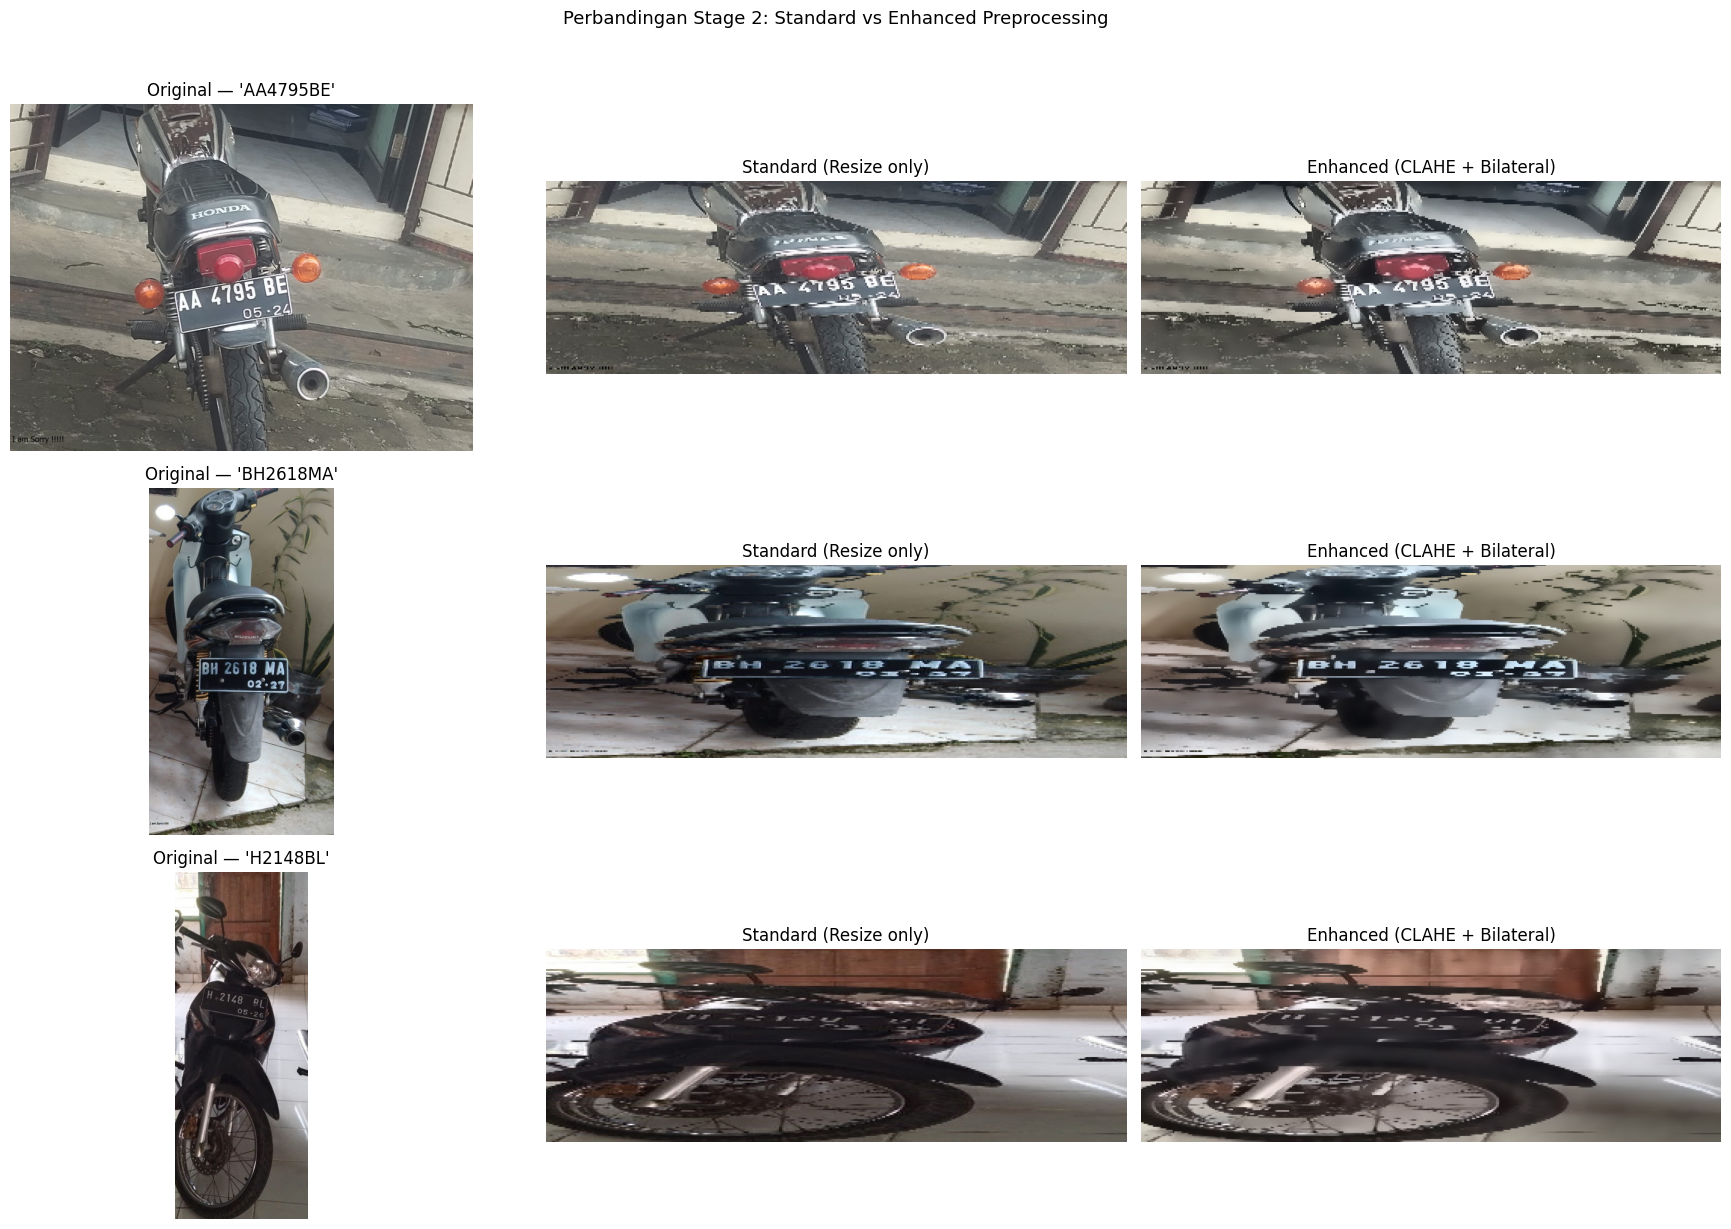

In [9]:
# ============================================================
# Cell 3.2 — Fungsi Image Enhancement
# ============================================================

def enhance_plate_standard(crop_rgb, target_w=OCR_IMG_WIDTH, target_h=OCR_IMG_HEIGHT):
    """
    Enhancement minimal: hanya resize ke ukuran target.
    Digunakan untuk Pipeline-A dan Pipeline-B.
    """
    resized = cv2.resize(crop_rgb, (target_w, target_h), interpolation=cv2.INTER_LANCZOS4)
    return resized  # numpy RGB


def enhance_plate_enhanced(crop_rgb, target_w=OCR_IMG_WIDTH, target_h=OCR_IMG_HEIGHT):
    """
    Enhancement lengkap untuk kondisi nyata (basement low-light, plat kotor):
      1. Resize ke target
      2. Convert ke LAB → CLAHE pada channel L (luminance)
      3. Bilateral Filter (noise reduction sambil menjaga tepi karakter)
      4. Kembalikan sebagai RGB

    CLAHE (clipLimit=2.0, tileGridSize=(8,4)):
      Meningkatkan kontras adaptif pada area karakter yang gelap/terang tidak merata.
      Sangat efektif untuk kondisi malam dengan lampu kendaraan.
    """
    # Resize
    img  = cv2.resize(crop_rgb, (target_w, target_h), interpolation=cv2.INTER_LANCZOS4)
    # RGB → BGR untuk OpenCV
    bgr  = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # LAB + CLAHE
    lab   = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 4))
    l     = clahe.apply(l)
    lab   = cv2.merge([l, a, b])
    bgr   = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # Bilateral Filter
    bgr   = cv2.bilateralFilter(bgr, d=9, sigmaColor=75, sigmaSpace=75)

    # BGR → RGB
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


print("✅ Fungsi Image Enhancement siap.")

# Visualisasi efek enhancement pada crop plat sampel jika dataset tersedia
import matplotlib.pyplot as plt
import csv

if DS_TEXT_CSV and DS_TEXT_CSV.exists() and DS_TEXT_IMGS and DS_TEXT_IMGS.exists():
    sample_rows = []
    with open(DS_TEXT_CSV, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            sample_rows.append(row)
            if len(sample_rows) >= 3:
                break

    if sample_rows:
        fig, axes = plt.subplots(len(sample_rows), 3, figsize=(18, 4 * len(sample_rows)))
        if len(sample_rows) == 1:
            axes = [axes]

        for i, row in enumerate(sample_rows):
            img_bgr = cv2.imread(str(DS_TEXT_IMGS / row['filename']))
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            _, rectified = detect_plate_contour_and_rectify(img_rgb)
            standard  = enhance_plate_standard(img_rgb)
            enhanced  = enhance_plate_enhanced(img_rgb)

            axes[i][0].imshow(img_rgb)
            axes[i][0].set_title(f"Original — '{row['label']}'")
            axes[i][0].axis('off')

            axes[i][1].imshow(standard)
            axes[i][1].set_title('Standard (Resize only)')
            axes[i][1].axis('off')

            axes[i][2].imshow(enhanced)
            axes[i][2].set_title('Enhanced (CLAHE + Bilateral)')
            axes[i][2].axis('off')

        plt.suptitle('Perbandingan Stage 2: Standard vs Enhanced Preprocessing', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.savefig(WORK_DIR / 'stage2_enhancement_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("ℹ️ Dataset sampel belum tersedia untuk visualisasi preprocessing. Lanjut ke tahap berikutnya.")

---
## 🔤 Bagian 4: Stage 3 — TrOCR Recognizer

In [10]:
# ============================================================
# Cell 4.1 — Load Semua TrOCR Model dari NB2
# ============================================================
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from pathlib import Path
import json

ocr_models     = {}  # {exp_id: model}
ocr_processors = {}  # {exp_id: processor}

# 1. Coba load dari ocr_detected_dirs (Auto-detect pintar)
if 'ocr_detected_dirs' in globals() and ocr_detected_dirs:
    for exp_id, model_dir in ocr_detected_dirs.items():
        if model_dir.exists():
            try:
                print(f"Memuat TrOCR [{exp_id}] dari: {model_dir.name} ...")
                proc  = TrOCRProcessor.from_pretrained(str(model_dir))
                model = VisionEncoderDecoderModel.from_pretrained(str(model_dir))
                model.eval()
                model.to(DEVICE_STR)
                ocr_models[exp_id]     = model
                ocr_processors[exp_id] = proc
                print(f"✅ TrOCR [{exp_id}] loaded sukses!")
            except Exception as e:
                print(f"❌ Gagal load TrOCR [{exp_id}]: {e}")

# 2. Fallback: coba dari registry jika belum ada
if not ocr_models and OCR_MODELS_DIR:
    ocr_registry_path = OCR_MODELS_DIR / 'model_registry.json'
    if ocr_registry_path.exists():
        with open(ocr_registry_path) as f:
            ocr_registry = json.load(f)
        for exp_id, info in ocr_registry.items():
            model_dir = Path(info.get('directory', ''))
            if not model_dir.exists() and (OCR_MODELS_DIR / model_dir.name).exists():
                model_dir = OCR_MODELS_DIR / model_dir.name
            if model_dir.exists():
                try:
                    proc  = TrOCRProcessor.from_pretrained(str(model_dir))
                    model = VisionEncoderDecoderModel.from_pretrained(str(model_dir))
                    model.eval()
                    model.to(DEVICE_STR)
                    ocr_models[exp_id]     = model
                    ocr_processors[exp_id] = proc
                    print(f"✅ TrOCR [{exp_id}] loaded dari: {model_dir.name}")
                except Exception as e:
                    print(f"❌ Gagal load TrOCR [{exp_id}]: {e}")

print(f"\nTotal TrOCR model loaded: {len(ocr_models)}")

Memuat TrOCR [Exp-B] dari: OCR Extraction Text Weight EXP 2 ...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

✅ TrOCR [Exp-B] loaded sukses!

Total TrOCR model loaded: 1


In [11]:
# ============================================================
# Cell 4.2 — Fungsi OCR (per gambar crop)
# ============================================================

def recognize_plate_text(crop_rgb_np, processor, model,
                          max_length=MAX_TOKEN_LEN, num_beams=NUM_BEAMS):
    """
    Baca teks plat nomor dari crop gambar menggunakan TrOCR.

    Args:
        crop_rgb_np : numpy array (H, W, 3) RGB
        processor   : TrOCRProcessor
        model       : VisionEncoderDecoderModel
        max_length  : panjang maksimum token output
        num_beams   : jumlah beam untuk beam search (lebih tinggi = lebih akurat)

    Returns:
        str teks prediksi (raw, belum post-processing)
    """
    pil_img      = Image.fromarray(crop_rgb_np)
    pixel_values = processor(images=pil_img, return_tensors='pt').pixel_values
    pixel_values = pixel_values.to(DEVICE_STR)

    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_length  = max_length,
            num_beams   = num_beams,
        )

    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return text


print("✅ Fungsi OCR recognition siap.")

✅ Fungsi OCR recognition siap.


---
## ✅ Bagian 5: Stage 4 — Post-Processing & Validasi Format TNKB

In [12]:
# ============================================================
# Cell 5.1 — Post-Processing: Regex TNKB + Ambiguity Correction
# (Exhaustive Min-Changes Segmentation Engine)
# ============================================================
import re

# Format TNKB Indonesia baku:
#   [1-2 huruf prefix daerah] [1-4 digit nomor] [1-3 huruf suffix]
#   Contoh: 'B1234XYZ', 'AB1234CD', 'H5771OC'
TNKB_PATTERN = re.compile(r'^([A-Z]{1,2})([0-9]{1,4})([A-Z]{1,3})$')
TNKB_MAX_LEN = 9

def _try_segment(chars, p_end, n_end, digit_to_char=DIGIT_TO_CHAR, char_to_digit=CHAR_TO_DIGIT):
    """
    Uji apakah segmentasi (prefix=0..p_end, nomor=p_end+1..n_end, suffix=n_end+1..end)
    dapat membentuk format TNKB yang valid dengan minimal penggantian karakter.
    """
    n = len(chars)
    if not (1 <= p_end + 1 <= 2):          return None, 0
    if not (1 <= n_end - p_end <= 4):      return None, 0
    if not (1 <= n - n_end - 1 <= 3):      return None, 0

    result  = list(chars)
    changes = 0

    # Prefix (harus huruf)
    for i in range(0, p_end + 1):
        c = result[i]
        if c.isdigit():
            new = digit_to_char.get(c, c)
            result[i] = new
            if new != c: changes += 1

    # Nomor (harus digit)
    for i in range(p_end + 1, n_end + 1):
        c = result[i]
        if c.isalpha():
            new = char_to_digit.get(c, c)
            result[i] = new
            if new != c: changes += 1

    # Suffix (harus huruf)
    for i in range(n_end + 1, n):
        c = result[i]
        if c.isdigit():
            new = digit_to_char.get(c, c)
            result[i] = new
            if new != c: changes += 1

    return ''.join(result), changes


def correct_char_ambiguity(text_raw, digit_to_char=DIGIT_TO_CHAR, char_to_digit=CHAR_TO_DIGIT):
    """
    Koreksi karakter ambigu berdasarkan konteks posisi TNKB (exhaustive min-changes).
    Mencoba semua kemungkinan segmentasi prefix|nomor|suffix dan memilih
    yang menghasilkan format TNKB valid dengan perubahan sesedikit mungkin.

    Batas perubahan (anti over-correction):
      - String <= 7 karakter : maks 2 perubahan
      - String 8-9 karakter  : maks 1 perubahan
      - String > 9 karakter  : tidak dikoreksi
    """
    clean = re.sub(r'[^A-Z0-9]', '', text_raw.upper())
    n     = len(clean)
    if n < 3 or n > TNKB_MAX_LEN:
        return clean

    max_changes = 1 if n >= 8 else 2

    chars = list(clean)
    best_candidate = None
    best_changes   = float('inf')

    # Cari segmentasi terbaik
    for p_end in range(0, 2):
        for n_end in range(p_end + 1, p_end + 5):
            if n_end >= n:
                continue
            candidate, changes = _try_segment(chars, p_end, n_end, digit_to_char, char_to_digit)
            if candidate is None:
                continue
            if (TNKB_PATTERN.match(candidate)
                    and changes < best_changes
                    and changes <= max_changes):
                best_changes   = changes
                best_candidate = candidate

    return best_candidate if best_candidate is not None else clean


def validate_tnkb_format(text, pattern=TNKB_PATTERN):
    """Validasi apakah teks sesuai format TNKB Indonesia."""
    text_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
    match      = pattern.match(text_clean)
    if match:
        return True, match.groups()
    return False, None


def postprocess_plate_text(raw_text, apply_correction=True):
    """
    Pipeline post-processing lengkap:
      1. Uppercase + hapus karakter non-alfanumerik
      2. Koreksi ambiguitas karakter (posisi TNKB)
      3. Validasi format TNKB
    """
    cleaned   = re.sub(r'[^A-Z0-9]', '', raw_text.upper())
    corrected = correct_char_ambiguity(cleaned) if apply_correction else cleaned
    is_valid, groups = validate_tnkb_format(corrected)

    return {
        'raw'      : raw_text,
        'cleaned'  : cleaned,
        'corrected': corrected,
        'valid'    : is_valid,
        'groups'   : groups,
        'final'    : corrected,
    }


# ─── Unit Test Post-Processing ────────────────────────────────────────────────
print("=" * 60)
print("Unit Test Post-Processing (Exhaustive Min-Changes)")
print("=" * 60)
test_cases = [
    ('B1234XYZ',   'B1234XYZ'),   # Sudah benar
    ('81234XYZ',   'B1234XYZ'),   # '8' di prefix → 'B'
    ('B1234X0Z',   'B1234XOZ'),   # '0' di suffix → 'O'
    ('BI234XYZ',   'BI234XYZ'),   # 'BI' valid 2 huruf prefix
    ('B12340Z',    'B1234OZ'),    # '0' di suffix → 'O'
    ('H 5771 OC',  'H5771OC'),    # Teks dengan spasi
    ('S4136SI',    'S4136SI'),    # Sudah benar format
    ('INVALID',    'INVALID'),    # Format tidak valid
]

for raw, expected in test_cases:
    result   = postprocess_plate_text(raw)
    final    = result['final']
    is_valid = result['valid']
    match    = '✅' if final == expected else f'❌ (got: {final})'
    print(f"  Input: '{raw:15s}' → Final: '{final:10s}' Valid: {str(is_valid):5s} {match}")


Unit Test Post-Processing
  Input: 'B1234XYZ       ' → Final: 'B1234XYZ  ' Valid: True  ✅
  Input: '81234XYZ       ' → Final: '81234XYZ  ' Valid: False ❌ (got: 81234XYZ)
  Input: 'B1234X0Z       ' → Final: 'B1234X0Z  ' Valid: False ❌ (got: B1234X0Z)
  Input: 'BI234XYZ       ' → Final: 'BI234XYZ  ' Valid: True  ❌ (got: BI234XYZ)
  Input: 'Bo234XYZ       ' → Final: 'BO234XYZ  ' Valid: True  ❌ (got: BO234XYZ)
  Input: 'H 5771 OC      ' → Final: 'H5771OC   ' Valid: True  ✅
  Input: 'INVALID        ' → Final: 'INVALID   ' Valid: False ✅


---
## 🏗️ Bagian 6: Kelas AlprSystem — Unified Pipeline

In [13]:
# ============================================================
# Cell 6.1 — Kelas AlprSystem
# ============================================================
import time

class AlprSystem:
    """
    Unified ALPR Pipeline untuk plat nomor Indonesia.

    Mengintegrasikan seluruh 4 tahap:
      Stage 1: YOLO Plate Detector    (NB1)
      Stage 2: Crop + Perspective Correction + Image Enhancement  (OpenCV)
      Stage 3: TrOCR Text Recognizer  (NB2)
      Stage 4: Post-Processing & Format Validation (Regex)

    Args:
        yolo_model      : YOLO instance
        ocr_processor   : TrOCRProcessor
        ocr_model       : VisionEncoderDecoderModel
        enhance_fn      : fungsi enhancement gambar (standard/enhanced)
        use_perspective : apakah mencoba perspective correction (default True)
        apply_postprocess: apakah terapkan post-processing Regex (default True)
        yolo_conf       : YOLO confidence threshold
        yolo_iou        : YOLO IoU threshold
    """

    def __init__(self,
                 yolo_model,
                 ocr_processor,
                 ocr_model,
                 enhance_fn      = enhance_plate_standard,
                 use_perspective  = True,
                 apply_postprocess= True,
                 yolo_conf        = YOLO_CONF,
                 yolo_iou         = YOLO_IOU):

        self.yolo_model       = yolo_model
        self.ocr_processor    = ocr_processor
        self.ocr_model        = ocr_model
        self.enhance_fn       = enhance_fn
        self.use_perspective  = use_perspective
        self.apply_postprocess = apply_postprocess
        self.yolo_conf         = yolo_conf
        self.yolo_iou          = yolo_iou


    def process_image(self, image_input):
        """
        Proses satu gambar melalui seluruh pipeline ALPR.

        Args:
            image_input: str path, PIL Image, atau numpy array (BGR/RGB)

        Returns:
            dict:
                'detections'   : list hasil deteksi YOLO
                'plates'       : list hasil OCR per plat
                'best_plate'   : plat dengan confidence tertinggi
                'time_ms'      : dict waktu per tahap
        """
        time_log = {}

        # ─── Load Gambar ──────────────────────────────────────────────────────
        t0 = time.perf_counter()
        if isinstance(image_input, str):
            img_bgr = cv2.imread(image_input)
            if img_bgr is None:
                raise FileNotFoundError(f"Gambar tidak ditemukan: {image_input}")
        elif isinstance(image_input, np.ndarray):
            # Asumsikan BGR (OpenCV default)
            img_bgr = image_input
        else:
            # PIL Image
            img_bgr = cv2.cvtColor(np.array(image_input), cv2.COLOR_RGB2BGR)
        time_log['load_ms'] = (time.perf_counter() - t0) * 1000

        # ─── Stage 1: YOLO Detection ─────────────────────────────────────────
        t0 = time.perf_counter()
        detections = detect_plates(
            self.yolo_model, img_bgr,
            conf=self.yolo_conf, iou=self.yolo_iou
        )
        time_log['detection_ms'] = (time.perf_counter() - t0) * 1000

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ─── Stage 2 + 3 + 4: Per Deteksi ───────────────────────────────────
        plates_results = []
        t_stage2_total = 0
        t_stage3_total = 0
        t_stage4_total = 0

        for det in detections:
            # Stage 2a: Crop
            t0   = time.perf_counter()
            crop = crop_plate_from_image(img_bgr, det['xyxy'])

            # Stage 2b: Perspective Correction
            if self.use_perspective:
                crop, _ = detect_plate_contour_and_rectify(crop)

            # Stage 2c: Enhancement
            crop_enhanced = self.enhance_fn(crop)
            t_stage2_total += (time.perf_counter() - t0) * 1000

            # Stage 3: OCR
            t0       = time.perf_counter()
            raw_text = recognize_plate_text(
                crop_enhanced, self.ocr_processor, self.ocr_model
            )
            t_stage3_total += (time.perf_counter() - t0) * 1000

            # Stage 4: Post-Processing
            t0 = time.perf_counter()
            pp = postprocess_plate_text(raw_text, apply_correction=self.apply_postprocess)
            
            # ─── Fallback Khusus Plat 2 Baris (Masa Berlaku Pajak) ──────────
            # Jika hasil OCR hanya berupa digit (misal baris bawah '1219' terbaca)
            # atau tidak valid TNKB, coba crop 75% bagian atas plat (tempat nomor polisi)
            clean_digits = re.sub(r'[^A-Z0-9]', '', raw_text.upper())
            if (clean_digits.isdigit() or not pp['valid']) and crop_enhanced.shape[0] >= 30:
                top_h = int(crop_enhanced.shape[0] * 0.75)
                top_crop = crop_enhanced[:top_h, :]
                top_raw = recognize_plate_text(top_crop, self.ocr_processor, self.ocr_model)
                top_pp = postprocess_plate_text(top_raw, apply_correction=self.apply_postprocess)
                # Jika crop atas menghasilkan format valid atau mengandung huruf, gunakan hasil atas
                if top_pp['valid'] or (any(c.isalpha() for c in top_pp['final']) and len(top_pp['final']) >= 4):
                    raw_text = top_raw
                    pp = top_pp

            t_stage4_total += (time.perf_counter() - t0) * 1000

            plates_results.append({
                'xyxy'        : det['xyxy'],
                'yolo_conf'   : det['conf'],
                'raw_text'    : raw_text,
                'final_text'  : pp['final'],
                'valid_format': pp['valid'],
                'crop_rgb'    : crop,
                'crop_enhanced': crop_enhanced,
            })

        time_log['stage2_ms']    = t_stage2_total
        time_log['stage3_ms']    = t_stage3_total
        time_log['stage4_ms']    = t_stage4_total
        time_log['total_ms']     = sum(time_log.values())

        # Prioritaskan deteksi yang menghasilkan format TNKB valid;
        # jika tidak ada yang valid, ambil dengan YOLO confidence tertinggi.
        best_plate = None
        if plates_results:
            valid_plates = [p for p in plates_results if p['valid_format']]
            if valid_plates:
                best_plate = max(valid_plates, key=lambda x: x['yolo_conf'])
            else:
                best_plate = max(plates_results, key=lambda x: x['yolo_conf'])

        return {
            'detections' : detections,
            'plates'     : plates_results,
            'best_plate' : best_plate,
            'time_ms'    : time_log,
            'img_rgb'    : img_rgb,
        }


print("✅ Kelas AlprSystem siap digunakan.")

✅ Kelas AlprSystem siap digunakan.


---
## 🔬 Bagian 7: Definisi Konfigurasi Pipeline Eksperimen

In [14]:
# ============================================================
# Cell 7.1 — Definisi 4 Pipeline Eksperimen
# ============================================================
# Setiap pipeline mengombinasikan:
#   - YOLO model ID (dari NB1)
#   - OCR model ID  (dari NB2)
#   - Strategi enhancement gambar
#   - Apakah menggunakan perspective correction
#   - Apakah menggunakan post-processing Regex

# Pemilihan model cerdas: jika Exp-C tidak dilatih, gunakan Exp-B (model base 1.3 GB)
best_yolo = "Exp-C" if "Exp-C" in yolo_models else ("Exp-B" if "Exp-B" in yolo_models else "Exp-A")
best_ocr  = "Exp-C" if "Exp-C" in ocr_models else ("Exp-B" if "Exp-B" in ocr_models else "Exp-A")

PIPELINE_CONFIGS = {
    "Pipeline-A": {
        "description"      : "Baseline Cepat — YOLO11n + TrOCR-small, Standard (Tanpa CLAHE/Regex)",
        "yolo_exp_id"      : "Exp-A",
        "ocr_exp_id"       : "Exp-A",
        "enhance_fn"       : enhance_plate_standard,
        "use_perspective"  : False,
        "apply_postprocess": False,
    },
    "Pipeline-B": {
        "description"      : f"Baseline Akurasi — YOLO ({best_yolo}) + TrOCR Base ({best_ocr}), Standard + Regex",
        "yolo_exp_id"      : best_yolo,
        "ocr_exp_id"       : best_ocr,
        "enhance_fn"       : enhance_plate_standard,
        "use_perspective"  : True,
        "apply_postprocess": True,
    },
    "Pipeline-C": {
        "description"      : f"RECOMMENDED — YOLO ({best_yolo}) + TrOCR Base ({best_ocr}), Enhanced (CLAHE+Bilateral) + Full Post-Process",
        "yolo_exp_id"      : best_yolo,
        "ocr_exp_id"       : best_ocr,
        "enhance_fn"       : enhance_plate_enhanced,
        "use_perspective"  : True,
        "apply_postprocess": True,
    },
    "Pipeline-D": {
        "description"      : "Research — YOLO11m + TrOCR-base Synth→Real, Enhanced + Full",
        "yolo_exp_id"      : "Exp-D",
        "ocr_exp_id"       : "Exp-D",
        "enhance_fn"       : enhance_plate_enhanced,
        "use_perspective"  : True,
        "apply_postprocess": True,
    },
}

print("=" * 65)
print("KONFIGURASI PIPELINE EKSPERIMEN")
print("=" * 65)
for pid, cfg in PIPELINE_CONFIGS.items():
    yolo_ok = cfg['yolo_exp_id'] in yolo_models
    ocr_ok  = cfg['ocr_exp_id']  in ocr_models
    ready   = "✅" if (yolo_ok and ocr_ok) else "⚠️ Model belum ada"
    print(f"\n[{pid}] {cfg['description']}")
    print(f"  YOLO    : {cfg['yolo_exp_id']} {'✅' if yolo_ok else '❌'}")
    print(f"  OCR     : {cfg['ocr_exp_id']}  {'✅' if ocr_ok else '❌'}")
    print(f"  Enhance : {'Enhanced (CLAHE+Bilateral)' if cfg['enhance_fn'] == enhance_plate_enhanced else 'Standard'}")
    print(f"  Persp.  : {cfg['use_perspective']}")
    print(f"  PostProc: {cfg['apply_postprocess']}")
    print(f"  Status  : {ready}")

KONFIGURASI PIPELINE EKSPERIMEN

[Pipeline-A] Baseline Cepat — YOLO11n + TrOCR-small, Standard (Tanpa CLAHE/Regex)
  YOLO    : Exp-A ✅
  OCR     : Exp-A  ❌
  Enhance : Standard
  Persp.  : False
  PostProc: False
  Status  : ⚠️ Model belum ada

[Pipeline-B] Baseline Akurasi — YOLO (Exp-C) + TrOCR Base (Exp-B), Standard + Regex
  YOLO    : Exp-C ✅
  OCR     : Exp-B  ✅
  Enhance : Standard
  Persp.  : True
  PostProc: True
  Status  : ✅

[Pipeline-C] RECOMMENDED — YOLO (Exp-C) + TrOCR Base (Exp-B), Enhanced (CLAHE+Bilateral) + Full Post-Process
  YOLO    : Exp-C ✅
  OCR     : Exp-B  ✅
  Enhance : Enhanced (CLAHE+Bilateral)
  Persp.  : True
  PostProc: True
  Status  : ✅

[Pipeline-D] Research — YOLO11m + TrOCR-base Synth→Real, Enhanced + Full
  YOLO    : Exp-D ❌
  OCR     : Exp-D  ❌
  Enhance : Enhanced (CLAHE+Bilateral)
  Persp.  : True
  PostProc: True
  Status  : ⚠️ Model belum ada


In [15]:
# ============================================================
# Cell 7.2 — Inisialisasi Semua AlprSystem Instance
# ============================================================

alpr_systems = {}

for pid, cfg in PIPELINE_CONFIGS.items():
    yolo_id = cfg['yolo_exp_id']
    ocr_id  = cfg['ocr_exp_id']

    if yolo_id not in yolo_models or ocr_id not in ocr_models:
        print(f"⚠️ [{pid}] Lewati — YOLO {yolo_id} atau OCR {ocr_id} tidak tersedia.")
        continue

    alpr_systems[pid] = AlprSystem(
        yolo_model        = yolo_models[yolo_id],
        ocr_processor     = ocr_processors[ocr_id],
        ocr_model         = ocr_models[ocr_id],
        enhance_fn        = cfg['enhance_fn'],
        use_perspective   = cfg['use_perspective'],
        apply_postprocess = cfg['apply_postprocess'],
    )
    print(f"✅ [{pid}] AlprSystem siap.")

print(f"\nTotal pipeline siap: {len(alpr_systems)}")

⚠️ [Pipeline-A] Lewati — YOLO Exp-A atau OCR Exp-A tidak tersedia.
✅ [Pipeline-B] AlprSystem siap.
✅ [Pipeline-C] AlprSystem siap.
⚠️ [Pipeline-D] Lewati — YOLO Exp-D atau OCR Exp-D tidak tersedia.

Total pipeline siap: 2


---
## 📊 Bagian 8: Evaluasi End-to-End pada Test Set

In [16]:
# ============================================================
# Cell 8.1 — Load Dataset Evaluasi (Ground Truth)
# ============================================================

eval_pairs = []
test_pairs = []

if DS_TEXT_CSV and DS_TEXT_CSV.exists() and DS_TEXT_IMGS and DS_TEXT_IMGS.exists():
    with open(DS_TEXT_CSV, 'r', encoding='utf-8', errors='ignore') as f:
        reader = csv.DictReader(f)
        for row in reader:
            img_path = DS_TEXT_IMGS / row['filename']
            text     = row.get('label', '').strip().upper()
            if img_path.exists() and 4 <= len(text) <= 10:
                eval_pairs.append((str(img_path), text))

    random.seed(RANDOM_SEED)
    random.shuffle(eval_pairs)

    n_eval = int(len(eval_pairs) * 0.20)
    test_pairs = eval_pairs[:n_eval]

    print(f"Total data evaluasi   : {len(eval_pairs)}")
    print(f"Digunakan untuk test  : {len(test_pairs)} (20%)")
    print(f"Sample 5 pertama:")
    for img, text in test_pairs[:5]:
        print(f"  {Path(img).name:45s} → '{text}'")
else:
    print("⚠️ Dataset evaluasi CSV/dataset tidak ditemukan.")
    print("   Untuk evaluasi end-to-end akurasi, pastikan label.csv dan dataset/ tersedia.")

Total data evaluasi   : 1863
Digunakan untuk test  : 372 (20%)
Sample 5 pertama:
  KB2063LK.jpg                                  → 'KB2063LK'
  DataTrain33.png                               → 'B1629SJN'
  H3367YB_jpg.rf.c40c76b5ad082040682cc7f3b4ad2a2b.jpg → 'H3367YB'
  DataTrain798.png                              → 'AD1416YD'
  H2575AK_jpg.rf.cfd9307656e1c33d52ed44c26e8503ad.jpg → 'H2575AK'


In [17]:
# ============================================================
# Cell 8.2 — Fungsi Evaluasi Pipeline (End-to-End)
# ============================================================
cer_metric = eval_lib.load('cer')


def evaluate_pipeline(alpr_system, test_pairs, pipeline_id, verbose_interval=50):
    """
    Evaluasi end-to-end pipeline ALPR pada test set.

    Untuk setiap gambar:
      1. Jalankan AlprSystem.process_image()
      2. Ambil 'best_plate' (plat dengan YOLO conf tertinggi)
      3. Bandingkan 'final_text' dengan ground truth

    Catatan: Gambar dalam dataset evaluasi adalah CROP PLAT (bukan full kendaraan).
    YOLO pada crop ini mungkin tidak selalu mendeteksi (confidence rendah).
    Untuk kasus ini, kita juga evaluasi mode OCR-only (tanpa YOLO) sebagai referensi.

    Returns:
        dict berisi semua metrik evaluasi
    """
    preds  = []
    labels = []
    times  = []
    ocr_detected = 0
    no_detection = 0
    detail_log   = []

    for i, (img_path, gt_text) in enumerate(test_pairs):
        try:
            result = alpr_system.process_image(img_path)
            times.append(result['time_ms']['total_ms'])

            if result['best_plate']:
                pred_text = result['best_plate']['final_text']
                ocr_detected += 1
            else:
                # Fallback: jalankan OCR langsung pada gambar asli
                img_bgr = cv2.imread(img_path)
                if img_bgr is not None:
                    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                    crop_enh = alpr_system.enhance_fn(img_rgb)
                    raw_text = recognize_plate_text(
                        crop_enh,
                        alpr_system.ocr_processor,
                        alpr_system.ocr_model
                    )
                    pp = postprocess_plate_text(raw_text, alpr_system.apply_postprocess)
                    pred_text = pp['final']
                else:
                    pred_text = ''
                no_detection += 1

        except Exception as e:
            pred_text = ''
            no_detection += 1

        preds.append(pred_text)
        labels.append(gt_text)
        detail_log.append((img_path, gt_text, pred_text))

        if (i + 1) % verbose_interval == 0:
            running_cer  = cer_metric.compute(predictions=preds, references=labels)
            running_em   = sum(p == l for p, l in zip(preds, labels)) / len(labels)
            print(f"  [{pipeline_id}] {i+1}/{len(test_pairs)} | Running CER: {running_cer:.4f} | EM: {running_em*100:.1f}%")

    # Hitung metrik final
    cer_val     = cer_metric.compute(predictions=preds, references=labels)
    exact_match = sum(p == l for p, l in zip(preds, labels)) / len(labels)
    avg_time    = sum(times) / len(times) if times else 0

    return {
        'CER'                 : round(cer_val, 4),
        'Exact Match (%)'     : round(exact_match * 100, 2),
        'YOLO Detections'     : ocr_detected,
        'Fallback (no det.)'  : no_detection,
        'Avg Time/img (ms)'   : round(avg_time, 1),
        'Samples'             : len(test_pairs),
        '_detail'             : detail_log,
        '_preds'              : preds,
        '_labels'             : labels,
    }


print("✅ Fungsi evaluasi pipeline siap.")

✅ Fungsi evaluasi pipeline siap.


In [18]:
# ============================================================
# Cell 8.3 — PILIH PIPELINE YANG AKAN DIEVALUASI
#
# Evaluasi di T4x2 relatif cepat (hanya inference, bukan training).
# Bisa jalankan semua pipeline dalam satu sesi.
# ============================================================

PIPELINES_TO_EVAL = list(alpr_systems.keys())  # Evaluasi semua yang tersedia
print(f"Pipeline yang akan dievaluasi: {PIPELINES_TO_EVAL}")
print(f"Jumlah gambar uji            : {len(test_pairs)}")

Pipeline yang akan dievaluasi: ['Pipeline-B', 'Pipeline-C']
Jumlah gambar uji            : 372


In [19]:
# ============================================================
# Cell 8.4 — EKSEKUSI EVALUASI SEMUA PIPELINE
# ============================================================

pipeline_eval_results = {}

for pid in PIPELINES_TO_EVAL:
    if pid not in alpr_systems:
        print(f"⚠️ [{pid}] Tidak tersedia, lewati.")
        continue

    print(f"\n{'='*55}")
    print(f"  EVALUASI: [{pid}] {PIPELINE_CONFIGS[pid]['description']}")
    print(f"{'='*55}")

    try:
        eval_result = evaluate_pipeline(
            alpr_system = alpr_systems[pid],
            test_pairs  = test_pairs,
            pipeline_id = pid,
        )
        pipeline_eval_results[pid] = eval_result

        print(f"\n  ✅ [{pid}] Selesai:")
        print(f"     CER             : {eval_result['CER']}")
        print(f"     Exact Match     : {eval_result['Exact Match (%)']}%")
        print(f"     YOLO Detected   : {eval_result['YOLO Detections']}/{eval_result['Samples']}")
        print(f"     Avg Time/image  : {eval_result['Avg Time/img (ms)']} ms")

    except Exception as e:
        print(f"\n  ❌ [{pid}] Error: {e}")
        import traceback; traceback.print_exc()

print("\n" + "═" * 50)
print("SEMUA EVALUASI SELESAI")
print("═" * 50)


  EVALUASI: [Pipeline-B] Baseline Akurasi — YOLO (Exp-C) + TrOCR Base (Exp-B), Standard + Regex
  [Pipeline-B] 50/372 | Running CER: 0.1185 | EM: 60.0%
  [Pipeline-B] 100/372 | Running CER: 0.1448 | EM: 57.0%
  [Pipeline-B] 150/372 | Running CER: 0.1294 | EM: 58.0%
  [Pipeline-B] 200/372 | Running CER: 0.1188 | EM: 60.5%
  [Pipeline-B] 250/372 | Running CER: 0.1191 | EM: 60.4%
  [Pipeline-B] 300/372 | Running CER: 0.1117 | EM: 63.0%
  [Pipeline-B] 350/372 | Running CER: 0.1111 | EM: 61.7%

  ✅ [Pipeline-B] Selesai:
     CER             : 0.1115
     Exact Match     : 61.83%
     YOLO Detected   : 295/372
     Avg Time/image  : 321.0 ms

  EVALUASI: [Pipeline-C] RECOMMENDED — YOLO (Exp-C) + TrOCR Base (Exp-B), Enhanced (CLAHE+Bilateral) + Full Post-Process
  [Pipeline-C] 50/372 | Running CER: 0.1212 | EM: 60.0%
  [Pipeline-C] 100/372 | Running CER: 0.1448 | EM: 57.0%
  [Pipeline-C] 150/372 | Running CER: 0.1312 | EM: 58.0%
  [Pipeline-C] 200/372 | Running CER: 0.1195 | EM: 59.0%
  [Pip

---
## 📈 Bagian 9: Perbandingan & Visualisasi

In [20]:
# ============================================================
# Cell 9.1 — Tabel Perbandingan Lengkap Semua Pipeline
# ============================================================
import pandas as pd

summary_rows = []
for pid, res in pipeline_eval_results.items():
    cfg = PIPELINE_CONFIGS[pid]
    row = {
        'Pipeline'         : pid,
        'YOLO'             : cfg['yolo_exp_id'],
        'OCR'              : cfg['ocr_exp_id'],
        'Enhancement'      : 'Enhanced' if cfg['enhance_fn'] == enhance_plate_enhanced else 'Standard',
        'Perspective'      : 'Yes' if cfg['use_perspective'] else 'No',
        'Post-Process'     : 'Yes' if cfg['apply_postprocess'] else 'No',
        'CER'              : res['CER'],
        'Exact Match (%)'  : res['Exact Match (%)'],
        'YOLO Det. Rate'   : f"{res['YOLO Detections']}/{res['Samples']}",
        'Avg Time (ms)'    : res['Avg Time/img (ms)'],
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print("=" * 110)
print("TABEL PERBANDINGAN LENGKAP — END-TO-END ALPR PIPELINE — TEST SET")
print("=" * 110)
print(df_summary.to_string(index=False))

csv_path = WORK_DIR / 'pipeline_comparison.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\n✅ Disimpan ke: {csv_path}")

# Pipeline terbaik
if len(df_summary) > 0 and 'CER' in df_summary.columns:
    best_row = df_summary.loc[df_summary['CER'].idxmin()]
    print(f"\n🏆 Pipeline Terbaik (CER terendah): [{best_row['Pipeline']}]")
    print(f"   CER          : {best_row['CER']}")
    print(f"   Exact Match  : {best_row['Exact Match (%)']}%")
    print(f"   Avg Time     : {best_row['Avg Time (ms)']} ms/gambar")

TABEL PERBANDINGAN LENGKAP — END-TO-END ALPR PIPELINE — TEST SET
  Pipeline  YOLO   OCR Enhancement Perspective Post-Process    CER  Exact Match (%) YOLO Det. Rate  Avg Time (ms)
Pipeline-B Exp-C Exp-B    Standard         Yes          Yes 0.1115            61.83        295/372          321.0
Pipeline-C Exp-C Exp-B    Enhanced         Yes          Yes 0.1122            61.02        295/372          335.9

✅ Disimpan ke: /kaggle/working/alpr_master_pipeline/pipeline_comparison.csv

🏆 Pipeline Terbaik (CER terendah): [Pipeline-B]
   CER          : 0.1115
   Exact Match  : 61.83%
   Avg Time     : 321.0 ms/gambar


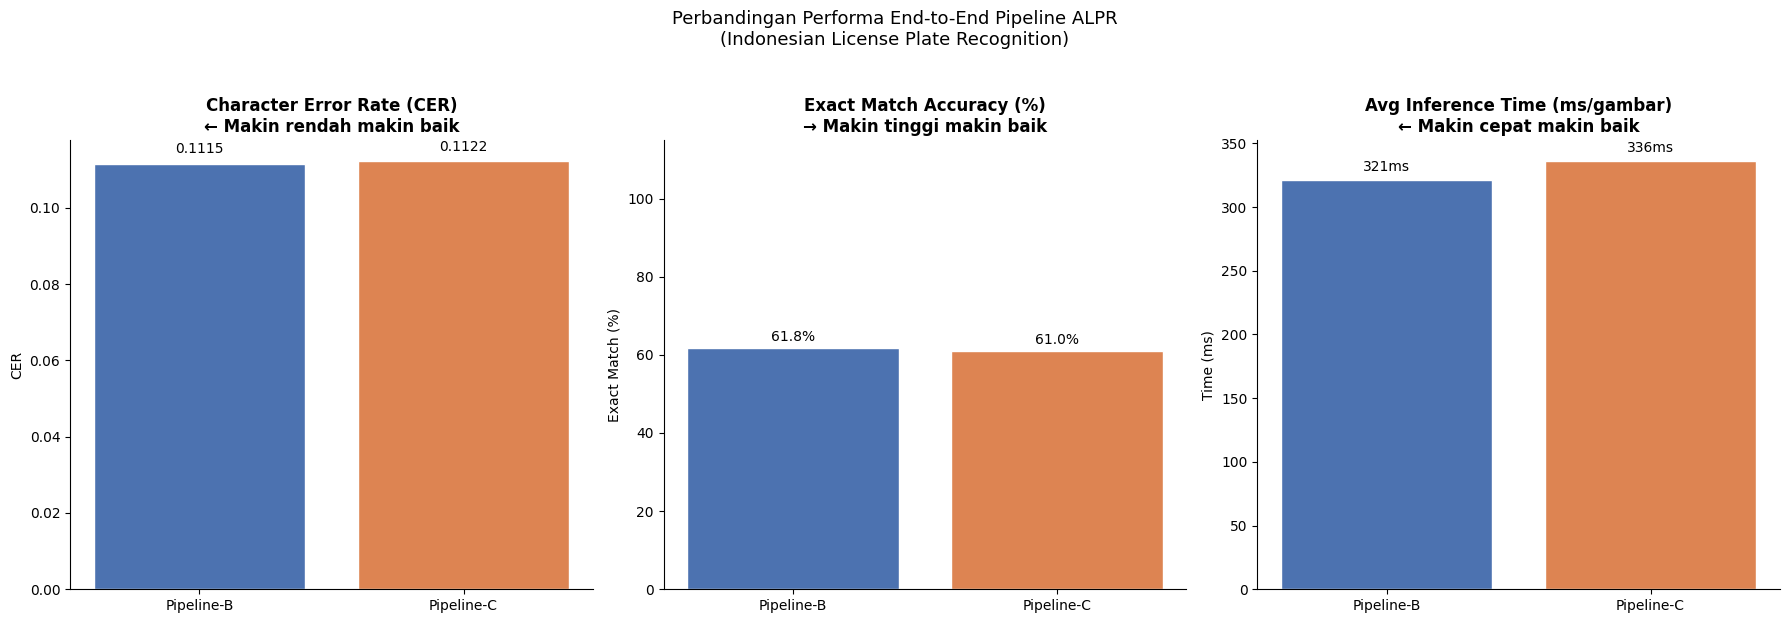

✅ Plot disimpan.


In [21]:
# ============================================================
# Cell 9.2 — Visualisasi Perbandingan Multi-Metrik
# ============================================================

if len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    pipe_labels = df_summary['Pipeline'].tolist()

    # Plot 1: CER
    cer_vals = df_summary['CER'].tolist()
    bars = axes[0].bar(pipe_labels, cer_vals, color=colors[:len(pipe_labels)], edgecolor='white')
    axes[0].set_title('Character Error Rate (CER)\n← Makin rendah makin baik', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('CER')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.002,
                     f'{h:.4f}', ha='center', va='bottom', fontsize=10)

    # Plot 2: Exact Match
    em_vals = df_summary['Exact Match (%)'].tolist()
    bars = axes[1].bar(pipe_labels, em_vals, color=colors[:len(pipe_labels)], edgecolor='white')
    axes[1].set_title('Exact Match Accuracy (%)\n→ Makin tinggi makin baik', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Exact Match (%)')
    axes[1].set_ylim(0, 115)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., h + 1,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

    # Plot 3: Speed (ms per image)
    time_vals = df_summary['Avg Time (ms)'].tolist()
    bars = axes[2].bar(pipe_labels, time_vals, color=colors[:len(pipe_labels)], edgecolor='white')
    axes[2].set_title('Avg Inference Time (ms/gambar)\n← Makin cepat makin baik', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Time (ms)')
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)
    for bar in bars:
        h = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., h + 5,
                     f'{h:.0f}ms', ha='center', va='bottom', fontsize=10)

    plt.suptitle('Perbandingan Performa End-to-End Pipeline ALPR\n(Indonesian License Plate Recognition)',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'pipeline_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot disimpan.")

In [22]:
# ============================================================
# Cell 9.3 — Tabel Prediksi Kualitatif per Pipeline
# ============================================================

print("=" * 70)
print("SAMPLE PREDIKSI vs GROUND TRUTH — 15 SAMPEL PERTAMA per PIPELINE")
print("=" * 70)

for pid, res in pipeline_eval_results.items():
    samples = list(zip(res['_preds'][:15], res['_labels'][:15]))
    print(f"\n[{pid}] {PIPELINE_CONFIGS[pid]['description']}")
    print(f"  {'No':>3}  {'Ground Truth':>12}  {'Prediksi':>12}  {'Match':>6}")
    print(f"  {'─'*3}  {'─'*12}  {'─'*12}  {'─'*6}")
    for i, (pred, true) in enumerate(samples, 1):
        match = '✅' if pred == true else '❌'
        print(f"  {i:>3}  {true:>12}  {pred:>12}  {match}")

SAMPLE PREDIKSI vs GROUND TRUTH — 15 SAMPEL PERTAMA per PIPELINE

[Pipeline-B] Baseline Akurasi — YOLO (Exp-C) + TrOCR Base (Exp-B), Standard + Regex
   No  Ground Truth      Prediksi   Match
  ───  ────────────  ────────────  ──────
    1      KB2063LK      KO2063LK  ❌
    2      B1629SJN      B1629SJN  ✅
    3       H3367YB       H3367YB  ✅
    4      AD1416YD      AD1416YD  ✅
    5       H2575AK        2575AK  ❌
    6       H6998ZL       H6998ZL  ✅
    7       S4136SI       44136SI  ❌
    8       B1125OP       B1125OP  ✅
    9      B1946TKN      B1946TKN  ✅
   10       E2462QF       E2462QF  ✅
   11       E5905QO          1219  ❌
   12       H3979JA         H3979  ❌
   13      AB6677RU        AB6677  ❌
   14       K4997XC       K4997XC  ✅
   15      B1690ZKL      B1690ZKL  ✅

[Pipeline-C] RECOMMENDED — YOLO (Exp-C) + TrOCR Base (Exp-B), Enhanced (CLAHE+Bilateral) + Full Post-Process
   No  Ground Truth      Prediksi   Match
  ───  ────────────  ────────────  ──────
    1      KB2063

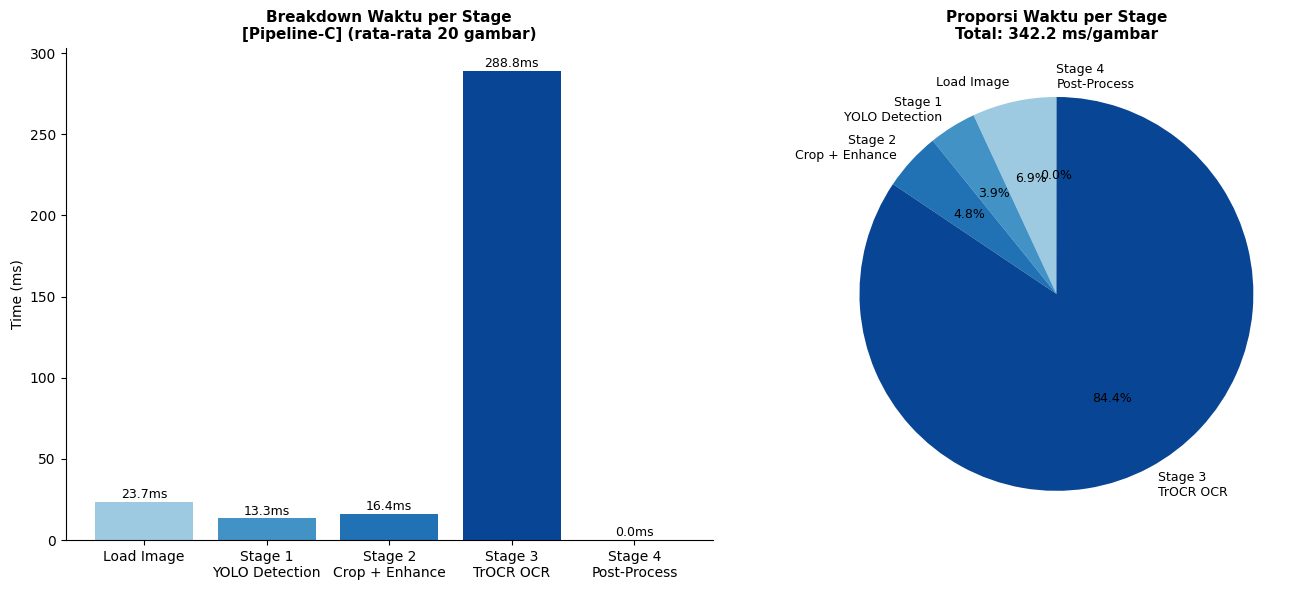


Breakdown Waktu [Pipeline-C]:
  Load Image               :   23.7 ms (6.9%)
  Stage 1 YOLO Detection   :   13.3 ms (3.9%)
  Stage 2 Crop + Enhance   :   16.4 ms (4.8%)
  Stage 3 TrOCR OCR        :  288.8 ms (84.4%)
  Stage 4 Post-Process     :    0.0 ms (0.0%)
  TOTAL                    :  342.2 ms


In [23]:
# ============================================================
# Cell 9.4 — Analisis Waktu per Stage (Best Pipeline)
# ============================================================

# Jalankan sekali lagi untuk mendapatkan breakdown waktu per stage
if pipeline_eval_results:
    # Pilih Pipeline-C (recommended) atau yang tersedia
    demo_pid = 'Pipeline-C' if 'Pipeline-C' in alpr_systems else list(alpr_systems.keys())[0]
    demo_sys = alpr_systems[demo_pid]

    # Jalankan 20 gambar untuk mendapatkan rata-rata waktu per stage
    sample_imgs = [img for img, _ in test_pairs[:20]]
    stage_times = {'load': [], 'detection': [], 'stage2': [], 'stage3': [], 'stage4': []}

    for img_path in sample_imgs:
        result = demo_sys.process_image(img_path)
        t = result['time_ms']
        stage_times['load'].append(t.get('load_ms', 0))
        stage_times['detection'].append(t.get('detection_ms', 0))
        stage_times['stage2'].append(t.get('stage2_ms', 0))
        stage_times['stage3'].append(t.get('stage3_ms', 0))
        stage_times['stage4'].append(t.get('stage4_ms', 0))

    avg_times = {k: sum(v)/len(v) for k, v in stage_times.items()}
    stage_labels = [
        'Load Image',
        'Stage 1\nYOLO Detection',
        'Stage 2\nCrop + Enhance',
        'Stage 3\nTrOCR OCR',
        'Stage 4\nPost-Process',
    ]
    stage_vals = list(avg_times.values())
    total_avg  = sum(stage_vals)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar chart waktu per stage
    bars = ax1.bar(stage_labels, stage_vals,
                   color=['#9ECAE1','#4292C6','#2171B5','#084594','#2CA02C'])
    ax1.set_title(f'Breakdown Waktu per Stage\n[{demo_pid}] (rata-rata 20 gambar)',
                  fontsize=11, fontweight='bold')
    ax1.set_ylabel('Time (ms)')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    for bar, val in zip(bars, stage_vals):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{val:.1f}ms', ha='center', va='bottom', fontsize=9)

    # Pie chart proporsi waktu
    wedge_colors = ['#9ECAE1','#4292C6','#2171B5','#084594','#2CA02C']
    ax2.pie(stage_vals, labels=stage_labels, colors=wedge_colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
    ax2.set_title(f'Proporsi Waktu per Stage\nTotal: {total_avg:.1f} ms/gambar',
                  fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(WORK_DIR / 'stage_timing_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nBreakdown Waktu [{demo_pid}]:")
    for label, val in zip(stage_labels, stage_vals):
        pct = val / total_avg * 100
        print(f"  {label.replace(chr(10),' '):25s}: {val:6.1f} ms ({pct:.1f}%)")
    print(f"  {'TOTAL':25s}: {total_avg:6.1f} ms")

---
## 🎯 Bagian 10: Demo Inferensi

Demo Pipeline: [Pipeline-C] RECOMMENDED — YOLO (Exp-C) + TrOCR Base (Exp-B), Enhanced (CLAHE+Bilateral) + Full Post-Process
Menampilkan 5 gambar...



/tmp/ipykernel_58/1695814948.py:60: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1695814948.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(WORK_DIR / f'demo_{pipeline_id.lower()}.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


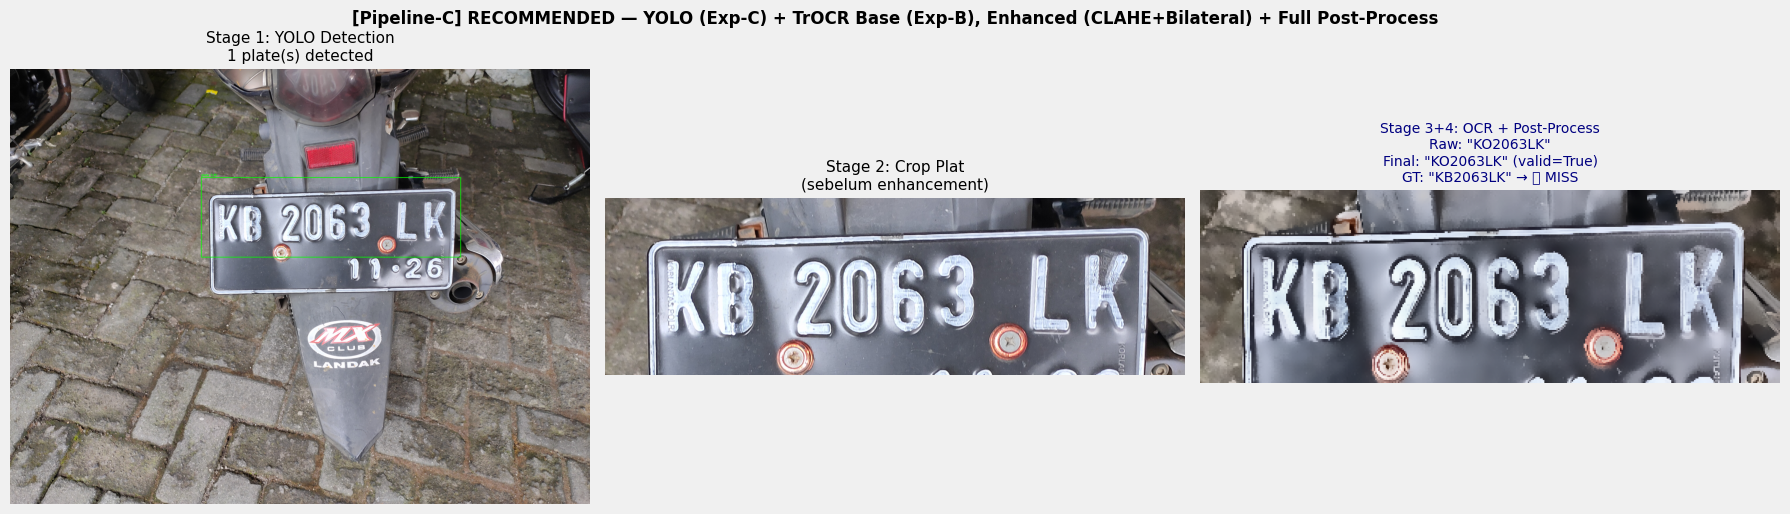

/tmp/ipykernel_58/1695814948.py:60: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1695814948.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(WORK_DIR / f'demo_{pipeline_id.lower()}.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


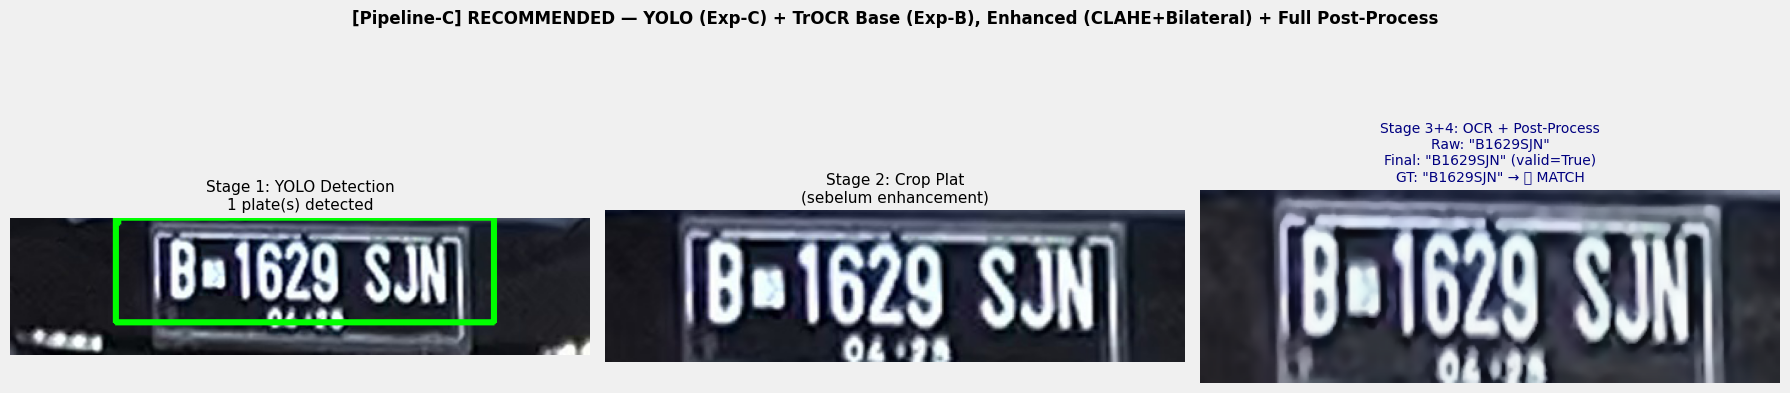

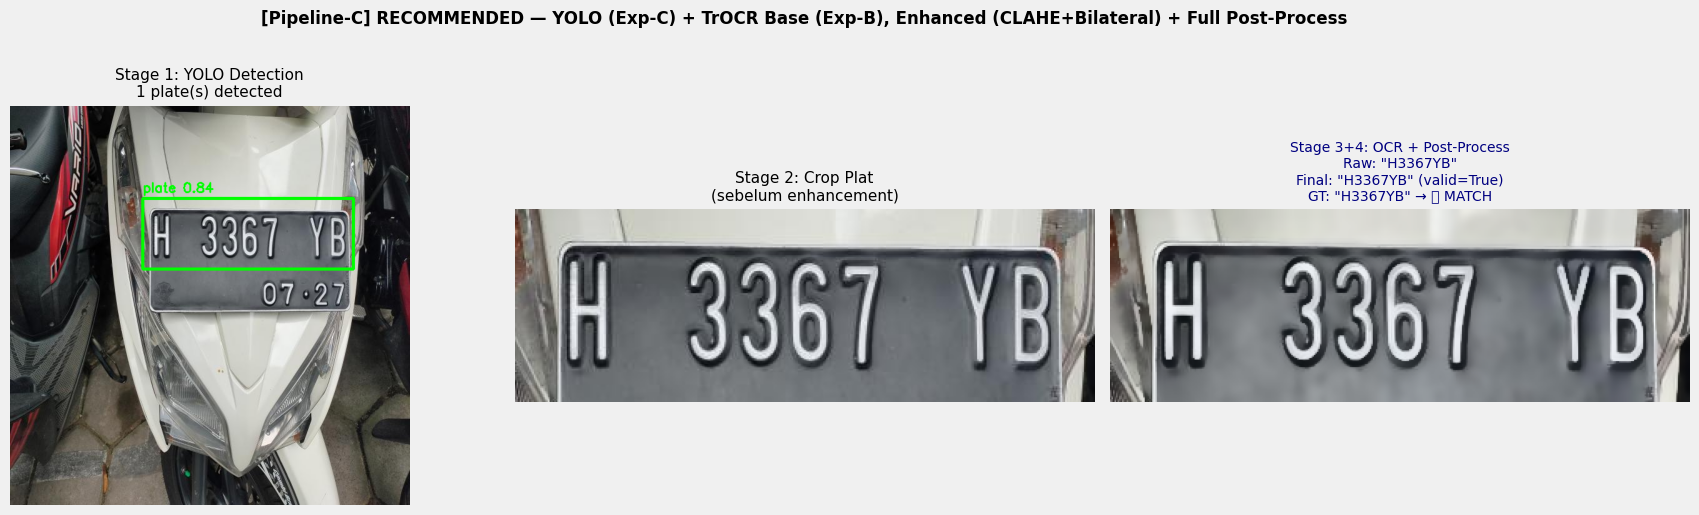

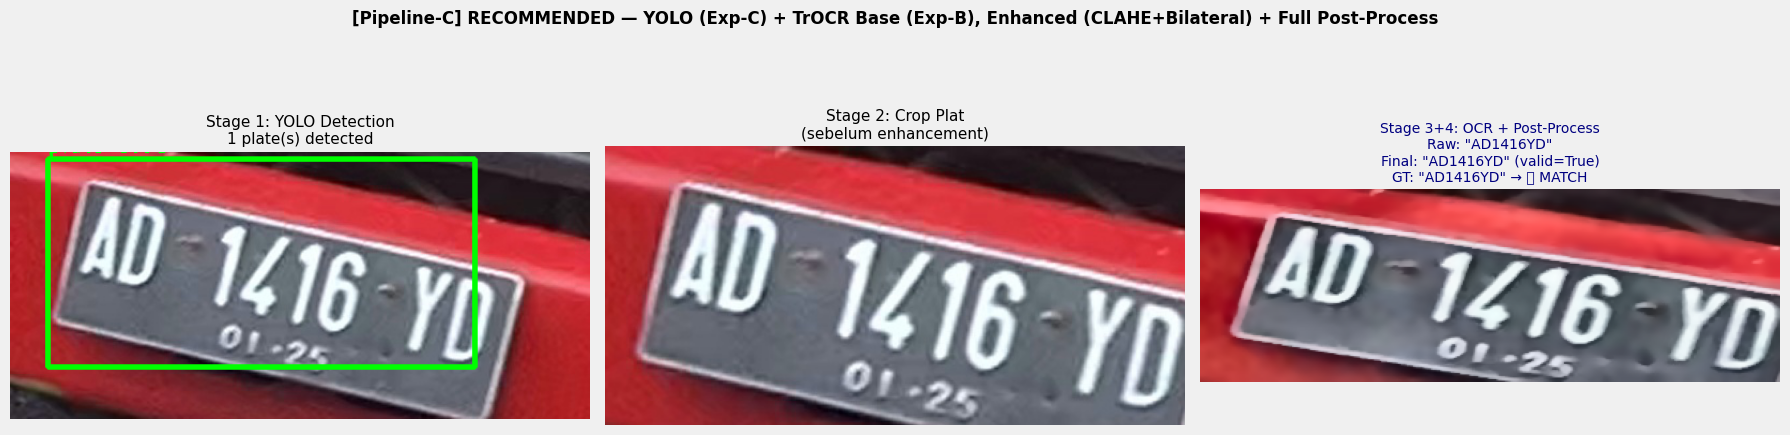

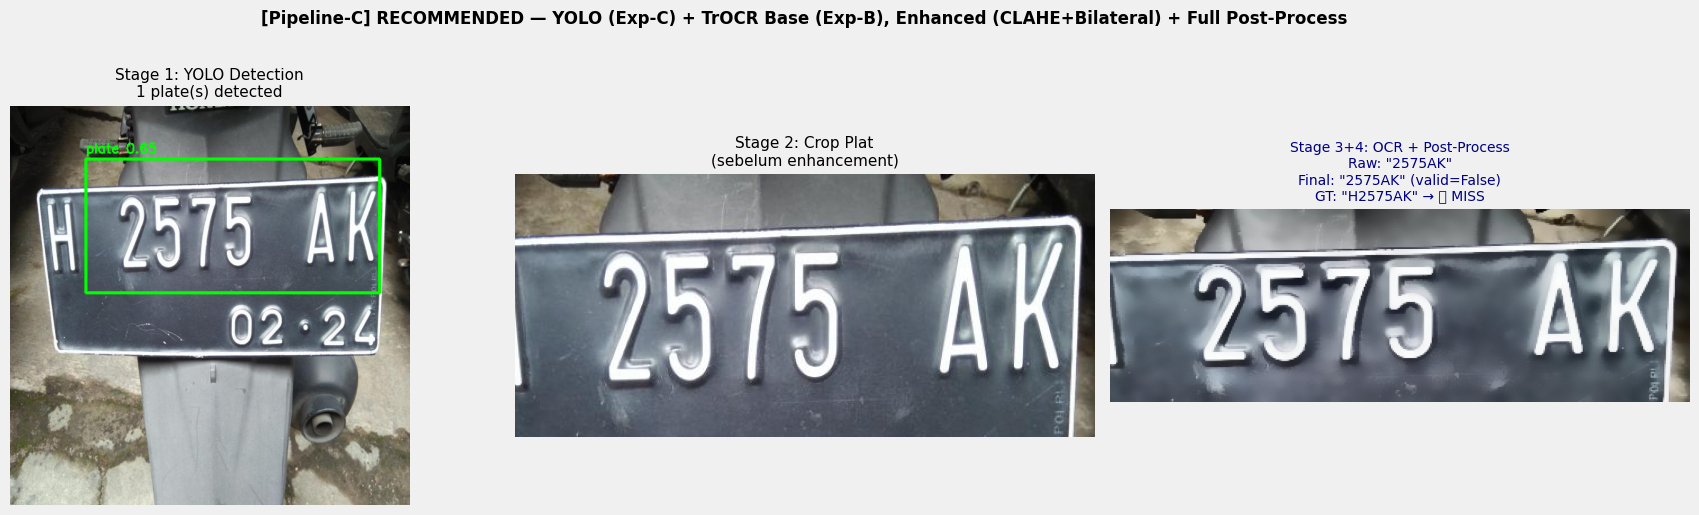

In [24]:
# ============================================================
# Cell 10.1 — Demo: Single Image Full Pipeline Visualization
# ============================================================

def visualize_pipeline_result(img_path, gt_text, alpr_system, pipeline_id):
    """
    Visualisasi lengkap hasil pipeline pada satu gambar:
      - Original image + YOLO bounding box
      - Crop plat (raw)
      - Crop plat (enhanced)
      - Teks prediksi vs ground truth
    """
    result = alpr_system.process_image(img_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor('#f0f0f0')

    # Panel 1: Gambar asli + bounding box
    img_rgb_annot = result['img_rgb'].copy()
    for det in result['detections']:
        x1, y1, x2, y2 = det['xyxy']
        cv2.rectangle(img_rgb_annot, (x1,y1), (x2,y2), (0,255,0), 3)
        cv2.putText(img_rgb_annot, f"plate {det['conf']:.2f}",
                    (x1, max(y1-10,0)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0,255,0), 2)
    axes[0].imshow(img_rgb_annot)
    axes[0].set_title(f'Stage 1: YOLO Detection\n'
                      f'{len(result["detections"])} plate(s) detected', fontsize=11)
    axes[0].axis('off')

    # Panel 2: Crop plat
    if result['best_plate']:
        axes[1].imshow(result['best_plate']['crop_rgb'])
        axes[1].set_title('Stage 2: Crop Plat\n(sebelum enhancement)', fontsize=11)
    else:
        axes[1].imshow(result['img_rgb'])
        axes[1].set_title('Stage 2: No Detection\n(gambar asli)', fontsize=11)
    axes[1].axis('off')

    # Panel 3: Crop enhanced + hasil OCR
    final_text = result['best_plate']['final_text'] if result['best_plate'] else '(no detection)'
    raw_text   = result['best_plate']['raw_text']   if result['best_plate'] else '-'
    is_valid   = result['best_plate']['valid_format'] if result['best_plate'] else False

    if result['best_plate']:
        axes[2].imshow(result['best_plate']['crop_enhanced'])
    else:
        axes[2].imshow(result['img_rgb'])

    match_str = '✅ MATCH' if final_text == gt_text else '❌ MISS'
    title_str = (f'Stage 3+4: OCR + Post-Process\n'
                 f'Raw: "{raw_text}"\n'
                 f'Final: "{final_text}" (valid={is_valid})\n'
                 f'GT: "{gt_text}" → {match_str}')
    axes[2].set_title(title_str, fontsize=10, color='navy')
    axes[2].axis('off')

    plt.suptitle(f'[{pipeline_id}] {PIPELINE_CONFIGS[pipeline_id]["description"]}',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(WORK_DIR / f'demo_{pipeline_id.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Demo dengan beberapa gambar dari test set menggunakan Pipeline-C
demo_pid = 'Pipeline-C' if 'Pipeline-C' in alpr_systems else list(alpr_systems.keys())[0]
demo_samples = test_pairs[:5]

print(f"Demo Pipeline: [{demo_pid}] {PIPELINE_CONFIGS[demo_pid]['description']}")
print(f"Menampilkan {len(demo_samples)} gambar...\n")

for img_path, gt_text in demo_samples:
    visualize_pipeline_result(img_path, gt_text, alpr_systems[demo_pid], demo_pid)

Membandingkan semua pipeline pada gambar: DataTrain468.png
Ground Truth: 'B1125OP'


/tmp/ipykernel_58/2254716552.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/2254716552.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(WORK_DIR / 'pipeline_cross_comparison.png', dpi=150, bbox_inches='tight')


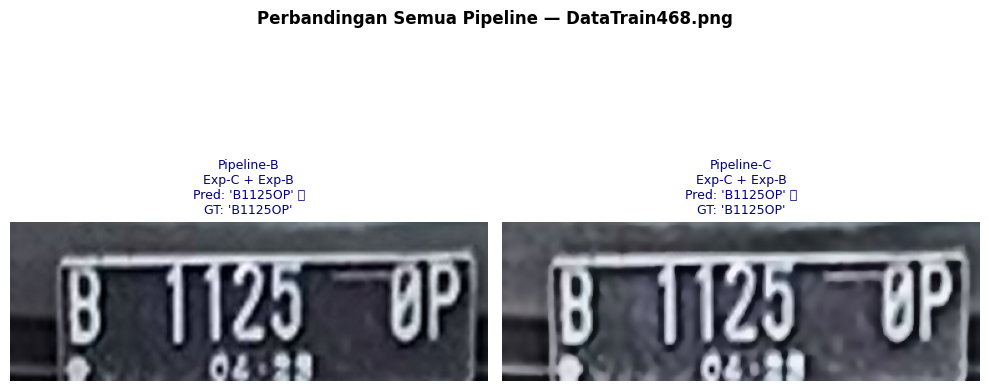

In [25]:
# ============================================================
# Cell 10.2 — Demo: Perbandingan Hasil Semua Pipeline pada Satu Gambar
# ============================================================

def compare_all_pipelines_on_image(img_path, gt_text, alpr_systems, pipeline_configs):
    """
    Tampilkan hasil semua pipeline pada satu gambar yang sama
    untuk perbandingan visual langsung.
    """
    n = len(alpr_systems)
    if n == 0:
        return

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]

    for i, (pid, sys) in enumerate(alpr_systems.items()):
        result     = sys.process_image(img_path)
        final_text = result['best_plate']['final_text'] if result['best_plate'] else '(no det.)'
        enhanced   = result['best_plate']['crop_enhanced'] if result['best_plate'] else result['img_rgb']

        axes[i].imshow(enhanced)
        match  = '✅' if final_text == gt_text else '❌'
        title  = (
            f"{pid}\n"
            f"{pipeline_configs[pid]['yolo_exp_id']} + {pipeline_configs[pid]['ocr_exp_id']}\n"
            f"Pred: '{final_text}' {match}\n"
            f"GT: '{gt_text}'"
        )
        axes[i].set_title(title, fontsize=9, color='navy')
        axes[i].axis('off')

    plt.suptitle(f'Perbandingan Semua Pipeline — {Path(img_path).name}',
                 fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'pipeline_cross_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# Pilih satu gambar yang menarik untuk dibandingkan
if test_pairs and alpr_systems:
    demo_img, demo_gt = test_pairs[7]
    print(f"Membandingkan semua pipeline pada gambar: {Path(demo_img).name}")
    print(f"Ground Truth: '{demo_gt}'")
    compare_all_pipelines_on_image(demo_img, demo_gt, alpr_systems, PIPELINE_CONFIGS)

In [26]:
# ============================================================
# Cell 10.3 — Demo: Inferensi Custom Image
#
# Ganti CUSTOM_IMAGE_PATH dengan path gambar kendaraan Anda.
# Ini mensimulasikan penggunaan sistem di dunia nyata.
# ============================================================

# ─── OPSIONAL: Ubah path ini dengan gambar kendaraan Anda ─────────────────────
CUSTOM_IMAGE_PATH = None  # Contoh: '/kaggle/input/my-test-images/car001.jpg'
# ──────────────────────────────────────────────────────────────────────────────

if CUSTOM_IMAGE_PATH and Path(CUSTOM_IMAGE_PATH).exists():
    demo_pid   = 'Pipeline-C' if 'Pipeline-C' in alpr_systems else list(alpr_systems.keys())[0]
    demo_sys   = alpr_systems[demo_pid]

    result = demo_sys.process_image(CUSTOM_IMAGE_PATH)

    print(f"\n{'='*55}")
    print(f"  HASIL INFERENSI CUSTOM IMAGE")
    print(f"  Pipeline: [{demo_pid}] {PIPELINE_CONFIGS[demo_pid]['description']}")
    print(f"{'='*55}")
    print(f"  Gambar         : {Path(CUSTOM_IMAGE_PATH).name}")
    print(f"  Jumlah plat    : {len(result['detections'])}")

    for j, plate in enumerate(result['plates']):
        print(f"\n  Plat #{j+1}:")
        print(f"    Bounding Box  : {plate['xyxy']}")
        print(f"    YOLO Conf     : {plate['yolo_conf']:.3f}")
        print(f"    Raw OCR       : '{plate['raw_text']}'")
        print(f"    Final         : '{plate['final_text']}'")
        print(f"    Format Valid  : {plate['valid_format']}")

    print(f"\n  Total Time     : {result['time_ms']['total_ms']:.1f} ms")

    # Visualisasi
    if result['plates']:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(result['img_rgb'])
        axes[0].set_title('Gambar Input')
        axes[0].axis('off')
        axes[1].imshow(result['plates'][0]['crop_rgb'])
        axes[1].set_title(f"Crop Plat\n'{result['plates'][0]['final_text']}'")
        axes[1].axis('off')
        axes[2].imshow(result['plates'][0]['crop_enhanced'])
        axes[2].set_title(f"Enhanced\n'{result['plates'][0]['final_text']}'")
        axes[2].axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("ℹ️ CUSTOM_IMAGE_PATH tidak diset atau file tidak ditemukan.")
    print("   Set variabel CUSTOM_IMAGE_PATH untuk mencoba gambar kendaraan Anda sendiri.")

ℹ️ CUSTOM_IMAGE_PATH tidak diset atau file tidak ditemukan.
   Set variabel CUSTOM_IMAGE_PATH untuk mencoba gambar kendaraan Anda sendiri.


---
## 💾 Bagian 11: Simpan Output & Ringkasan Akhir

In [27]:
# ============================================================
# Cell 11.1 — Simpan Laporan Evaluasi Lengkap
# ============================================================
import json
import shutil

# Simpan tabel perbandingan
df_summary.to_csv(WORK_DIR / 'pipeline_comparison.csv', index=False)

# Simpan detail prediksi per pipeline
for pid, res in pipeline_eval_results.items():
    detail_df = pd.DataFrame(
        [(Path(p).name, gt, pred, gt==pred)
         for p, gt, pred in res['_detail']],
        columns=['filename', 'ground_truth', 'prediction', 'exact_match']
    )
    detail_df.to_csv(WORK_DIR / f'detail_{pid.lower()}.csv', index=False)
    print(f"✅ Detail log [{pid}] disimpan.")

# Simpan seluruh evaluasi summary sebagai JSON
eval_summary_json = {}
for pid, res in pipeline_eval_results.items():
    eval_summary_json[pid] = {
        k: v for k, v in res.items() if not k.startswith('_')
    }

with open(WORK_DIR / 'evaluation_summary.json', 'w') as f:
    json.dump(eval_summary_json, f, indent=2)
print("✅ evaluation_summary.json disimpan.")

# Daftar semua output
print("\nSemua file output:")
for f in sorted(WORK_DIR.glob('*.*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")

✅ Detail log [Pipeline-B] disimpan.
✅ Detail log [Pipeline-C] disimpan.
✅ evaluation_summary.json disimpan.

Semua file output:
  demo_pipeline-c.png (1070.5 KB)
  detail_pipeline-b.csv (19.4 KB)
  detail_pipeline-c.csv (19.4 KB)
  evaluation_summary.json (0.4 KB)
  pipeline_comparison.csv (0.2 KB)
  pipeline_comparison.png (99.5 KB)
  pipeline_cross_comparison.png (309.2 KB)
  stage2_enhancement_comparison.png (2753.6 KB)
  stage_timing_analysis.png (113.8 KB)


In [28]:
# ============================================================
# Cell 11.2 — Ringkasan Akhir & Rekomendasi Deployment
# ============================================================

print("\n" + "═" * 75)
print("  📋 RINGKASAN AKHIR — NOTEBOOK 3: MASTER PIPELINE END-TO-END ALPR")
print("═" * 75)

print(f"\n🗂️  PIPELINE YANG DIEVALUASI: {len(pipeline_eval_results)}")
for pid in pipeline_eval_results:
    print(f"   [{pid}] {PIPELINE_CONFIGS[pid]['description']}")

print(f"\n📊 METRIK RINGKASAN (Test Set: {len(test_pairs)} gambar):")
if len(df_summary) > 0 and 'CER' in df_summary.columns:
    print(df_summary[['Pipeline','CER','Exact Match (%)','Avg Time (ms)']].to_string(index=False))

    best_row = df_summary.loc[df_summary['CER'].idxmin()]
    print(f"\n🏆 PIPELINE TERBAIK: [{best_row['Pipeline']}]")
    print(f"   CER              : {best_row['CER']}")
    print(f"   Exact Match      : {best_row['Exact Match (%)']}%")
    print(f"   Avg Time         : {best_row['Avg Time (ms)']} ms/gambar")

print(f"\n⚙️  ARSITEKTUR PIPELINE FINAL:")
print(f"   Stage 1  : YOLO11 License Plate Detector     → bounding box plat")
print(f"   Stage 2  : Crop + Perspective Correction     → plat terluruskan")
print(f"            + CLAHE + Bilateral Filter          → kontras optimal")
print(f"   Stage 3  : TrOCR Recognizer (fine-tuned)    → teks plat nomor")
print(f"   Stage 4  : Regex TNKB + Char Correction     → validasi format")

print(f"\n🔮 SARAN UNTUK DATASET B (Production):")
print(f"   1. Ambil footage dari kamera CCTV basement (resolusi asli, sudut riil)")
print(f"   2. Ekstrak frame → annotasi dengan format YOLO → fine-tune ulang YOLO")
print(f"   3. Crop plat dari footage basement → fine-tune ulang TrOCR")
print(f"   4. Tambahkan Tracker (ByteTrack) untuk video kontinu (multi-frame voting)")
print(f"   5. Sambungkan ke database entry/exit event")

print(f"\n📁 OUTPUT TERSIMPAN DI: /kaggle/working/alpr_master_pipeline/")
for f in sorted(WORK_DIR.glob('*.*')):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name} ({size_kb:.0f} KB)")

print("\n" + "═" * 75)
print("  ✅ NOTEBOOK 3 SELESAI — SISTEM ALPR INDONESIA SIAP")
print("═" * 75)


═══════════════════════════════════════════════════════════════════════════
  📋 RINGKASAN AKHIR — NOTEBOOK 3: MASTER PIPELINE END-TO-END ALPR
═══════════════════════════════════════════════════════════════════════════

🗂️  PIPELINE YANG DIEVALUASI: 2
   [Pipeline-B] Baseline Akurasi — YOLO (Exp-C) + TrOCR Base (Exp-B), Standard + Regex
   [Pipeline-C] RECOMMENDED — YOLO (Exp-C) + TrOCR Base (Exp-B), Enhanced (CLAHE+Bilateral) + Full Post-Process

📊 METRIK RINGKASAN (Test Set: 372 gambar):
  Pipeline    CER  Exact Match (%)  Avg Time (ms)
Pipeline-B 0.1115            61.83          321.0
Pipeline-C 0.1122            61.02          335.9

🏆 PIPELINE TERBAIK: [Pipeline-B]
   CER              : 0.1115
   Exact Match      : 61.83%
   Avg Time         : 321.0 ms/gambar

⚙️  ARSITEKTUR PIPELINE FINAL:
   Stage 1  : YOLO11 License Plate Detector     → bounding box plat
   Stage 2  : Crop + Perspective Correction     → plat terluruskan
            + CLAHE + Bilateral Filter          → kontras 